In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

train = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/test.csv')

#Limpieza de Datos

### 🧹 Limpieza e Imputación de Valores Nulos (NaN)

Limpiamos los valores faltantes (`NaN`) tanto para el conjunto de entrenamiento (`train`) como para el de prueba (`test`). La estrategia principal consiste en interpretar la ausencia de datos no como un error de registro, sino como la **inexistencia** de dicha característica en la propiedad.

* **Sótano (Basement):** Se observa que si el área total del sótano es cero (`TotalBsmtSF == 0`), significa que la casa no posee uno. Por lo tanto, los valores nulos en las variables categóricas relacionadas (`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`) se reemplazan con la etiqueta `'None'`.
* **Garage:** Bajo la misma premisa, la falta de datos indica la inexistencia de un garage. Para la variable numérica del año de construcción (`GarageYrBlt`) imputamos con `0`, mientras que para las características cualitativas (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`) utilizamos la categoría `'None'`.
* **Pileta y Chimenea:** La ausencia de registros en la calidad de la pileta (`PoolQC`) y en la chimenea (`FireplaceQu`) nos indica que la propiedad no cuenta con estas instalaciones. Se completan con `'None'`.
* **Área Decorativa (Masonry Veneer):** Para las casas que no poseen revestimiento de mampostería exterior, asignamos un valor de `0` en su área (`MasVnrArea`) y la etiqueta `'None'` en su tipo de material (`MasVnrType`).
* **Accesos y Extras (Alley, Fence, MiscFeature):** Las variables referentes al acceso por callejón (`Alley`), tipo de reja/cerca (`Fence`) y características misceláneas (`MiscFeature`) se completan con `'None'`, indicando que la vivienda no cuenta con estos elementos adicionales.

In [2]:
#Limpieza de datos del sotano, si tiene area 0, significa que no tiene sotano, cambio los NaN por 0

train[train['TotalBsmtSF'] == 0 | train['TotalBsmtSF'].isnull()][['BsmtUnfSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']]
#Las varibles a cambiar Nan por 0 son 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'

columnas_sotano_nan = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
train[columnas_sotano_nan] = train[columnas_sotano_nan].fillna('None')
test[columnas_sotano_nan] = test[columnas_sotano_nan].fillna('None')

In [3]:
#Limpieza de datos de garage, los que tienen el area con 0, no tienen garage

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

columnas_garage_nan = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
train[columnas_garage_nan] = train[columnas_garage_nan].fillna('None')
test[columnas_garage_nan] = test[columnas_garage_nan].fillna('None')

In [4]:
#Limpieza de datos de la pileta, los que tienen area de pileta 0, no tienen

train['PoolQC'] = train['PoolQC'].fillna('None')
test['PoolQC'] = test['PoolQC'].fillna('None')


In [5]:
#Limpieza de datos de la chimenea
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')
test['FireplaceQu'] = test['FireplaceQu'].fillna('None')

In [6]:
#Liempeza en area decorativa
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

train['MasVnrType'] = train['MasVnrType'].fillna('None')
test['MasVnrType'] = test['MasVnrType'].fillna('None')

In [7]:
#Limpieza en el acceso trasero

train['Alley'] = train['Alley'].fillna('None')
test['Alley'] = test['Alley'].fillna('None')

In [8]:
#Limpieza en las rejas
train['Fence'] = train['Fence'].fillna('None')
test['Fence'] = test['Fence'].fillna('None')

In [9]:
train['MiscFeature'] = train['MiscFeature'].fillna('None')
test['MiscFeature'] = test['MiscFeature'].fillna('None')

#Analisis Exploratorio de Datos

Despues de la limpieza, procedemos a realizar el **Análisis Exploratorio de Datos (EDA)**. El objetivo principal de esta fase es comprender a fondo la naturaleza de nuestras variables, descubrir patrones subyacentes y evaluar cómo se relacionan las diferentes características de las propiedades con nuestra variable objetivo (el precio de venta).

Durante esta sección, el análisis se estructurará en los siguientes puntos clave:

* **Distribución de la Variable Objetivo:** Analizaremos la distribución de los precios de venta (`SalePrice`) para observar su comportamiento, identificar posibles sesgos (asimetría) y determinar si es necesaria alguna transformación matemática para normalizar los datos antes del modelado.
* **Correlación de Variables Numéricas:** Mediante matrices de correlación y mapas de calor (*heatmaps*), identificaremos qué características cuantitativas (como el área habitable total, el tamaño del garaje o la antigüedad) tienen una relación lineal más fuerte con el precio.
* **Comportamiento de Variables Categóricas:** Utilizaremos gráficos de caja (*boxplots*) y de barras para explorar cómo fluctúan los precios en función de atributos cualitativos clave, como la calidad general de los materiales, la zona de la vivienda o el tipo de sótano.
* **Identificación de Valores Atípicos (Outliers):** Buscaremos propiedades que presenten valores extremos o atípicos (por ejemplo, casas con un área de construcción enorme pero un precio inusualmente bajo) para evaluar si es conveniente mantenerlas o filtrarlas del conjunto de entrenamiento.

In [10]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [11]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
train['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [13]:
#cantidad de barrios
train['Neighborhood'].nunique()

25

In [14]:
#nombre de los barrios
train['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [15]:
#precios promedio, maximo y minimo por barrio
precio_por_barrio = train.groupby('Neighborhood')['SalePrice'].describe().reset_index()
precio_por_barrio.sort_values(by='Neighborhood', ascending=False)

,Neighborhood,count,mean,std,min,25%,50%,75%,max
24,Veenker,11.0,238772.727273,72369.317959,162500.0,184250.00,218000.0,282000.00,385000.0
23,Timber,38.0,242247.447368,64845.651549,137500.0,186900.00,228475.0,286115.75,378500.0
22,StoneBr,25.0,310499.000000,112969.676640,170000.0,213500.00,278000.0,377426.00,556581.0
21,Somerst,86.0,225379.837209,56177.555888,144152.0,177975.00,225500.0,252919.50,423000.0
20,SawyerW,59.0,186555.796610,55651.997820,76000.0,145500.00,179900.0,222500.00,320000.0
19,Sawyer,74.0,136793.135135,22345.129157,62383.0,127250.00,135000.0,149462.50,190000.0
18,SWISU,25.0,142591.360000,32622.917679,60000.0,128000.00,139500.0,160000.00,200000.0
17,OldTown,113.0,128225.300885,52650.583185,37900.0,105900.00,119000.0,140000.00,475000.0
16,NridgHt,77.0,316270.623377,96392.544954,154000.0,253293.00,315000.0,374000.00,611657.0
15,NoRidge,41.0,335295.317073,121412.658640,190000.0,265000.00,301500.0,341000.00,755000.0


In [16]:
train.groupby('Neighborhood')['LotArea'].describe().reset_index().sort_values(by='mean', ascending=False)

,Neighborhood,count,mean,std,min,25%,50%,75%,max
4,ClearCr,28.0,30875.750000,34777.377591,2887.0,11114.50,17575.0,37151.00,159000.0
23,Timber,38.0,23664.236842,41074.756760,6853.0,10739.75,12781.5,14584.75,215245.0
24,Veenker,11.0,15606.000000,11832.672851,9549.0,10184.00,11120.0,15560.00,50271.0
15,NoRidge,41.0,14218.902439,7332.628883,9200.0,10437.00,12090.0,14720.00,46589.0
14,NWAmes,73.0,11833.630137,2682.998610,8400.0,10140.00,11029.0,12243.00,20781.0
6,Crawfor,51.0,11809.686275,5315.343377,3842.0,7573.00,11500.0,14278.50,32668.0
11,Mitchel,49.0,11624.285714,6025.812141,4500.0,8314.00,9947.0,12508.00,32463.0
8,Gilbert,79.0,11379.151899,4679.548480,7415.0,8184.50,9967.0,12309.00,34650.0
16,NridgHt,77.0,10887.948052,3637.945957,2268.0,8769.00,11694.0,13478.00,20431.0
22,StoneBr,25.0,10671.920000,9892.293347,3696.0,5330.00,6820.0,12438.00,53504.0


In [17]:
#tipo de zona por barrio
train.groupby('Neighborhood')['MSZoning'].unique()

,MSZoning
Neighborhood,
Blmngtn,"[RL, RM]"
Blueste,[RM]
BrDale,[RM]
BrkSide,"[RL, RM]"
ClearCr,[RL]
CollgCr,"[RL, RM]"
Crawfor,"[RL, RM, RH]"
Edwards,"[RL, RM, RH]"
Gilbert,[RL]


In [18]:
#cantidad de ventas por barrio
train.groupby(['Neighborhood'])['Id'].count().sort_values(ascending=False)

,Id
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


In [19]:
#precio por estilo de casa
train.groupby('MSSubClass')['SalePrice'].describe()

,count,mean,std,min,25%,50%,75%,max
MSSubClass,,,,,,,,
20,536.0,185224.811567,78782.189967,35311.0,132500.0,159250.0,220000.0,611657.0
30,69.0,95829.724638,24857.110083,34900.0,81000.0,99900.0,110500.0,163500.0
40,4.0,156125.000000,75747.799748,79500.0,119625.0,142500.0,179000.0,260000.0
45,12.0,108591.666667,20231.723889,76000.0,94125.0,107500.0,122250.0,139400.0
50,144.0,143302.972222,54851.983707,37900.0,114125.0,132000.0,159000.0,410000.0
60,299.0,239948.501672,86579.909966,129000.0,185000.0,215200.0,268750.0,755000.0
70,60.0,166772.416667,58206.545762,40000.0,128000.0,156000.0,189500.0,359100.0
75,16.0,192437.500000,100556.762577,101000.0,125625.0,163500.0,219625.0,475000.0
80,58.0,169736.551724,38197.808771,107000.0,147250.0,166500.0,179425.0,345000.0


####Análisis Temporal del Volumen de Ventas (Mes vs. Año)

Para comprender la dinámica temporal del mercado inmobiliario y detectar patrones estacionales, creamos una tabla de contingencia cruzando el mes de venta (`MoSold`) con el año de venta (`YrSold`), representando los resultados mediante un mapa de calor (*heatmap*).

Esta visualización nos permite responder a preguntas clave sobre el comportamiento del negocio:
* **Estacionalidad del mercado:** Identificar de forma inmediata cuáles son los meses "pico" del año donde se concreta la mayor cantidad de transacciones (típicamente los meses de primavera y verano debido al clima y recesos escolares) y cuáles son las épocas de menor actividad.
* **Tendencia interanual:** Evaluar si el volumen general de ventas se mantuvo estable, creció o sufrió caídas drásticas a lo largo de los años registrados en el dataset.
* **Consistencia de los datos:** Verificar si la recolección de datos cubre todos los períodos completos o si existe algún año de corte (por ejemplo, si el último año del registro tiene celdas en cero a partir de cierto mes porque se detuvo la toma de muestras).

In [20]:
#años de venta
train['YrSold'].unique()

array([2008, 2007, 2006, 2009, 2010])

In [21]:
train['YearBuilt'].unique()

array([2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939, 1965,
       2005, 1962, 2006, 1960, 1929, 1970, 1967, 1958, 1930, 2002, 1968,
       2007, 1951, 1957, 1927, 1920, 1966, 1959, 1994, 1954, 1953, 1955,
       1983, 1975, 1997, 1934, 1963, 1981, 1964, 1999, 1972, 1921, 1945,
       1982, 1998, 1956, 1948, 1910, 1995, 1991, 2009, 1950, 1961, 1977,
       1985, 1979, 1885, 1919, 1990, 1969, 1935, 1988, 1971, 1952, 1936,
       1923, 1924, 1984, 1926, 1940, 1941, 1987, 1986, 2008, 1908, 1892,
       1916, 1932, 1918, 1912, 1947, 1925, 1900, 1980, 1989, 1992, 1949,
       1880, 1928, 1978, 1922, 1996, 2010, 1946, 1913, 1937, 1942, 1938,
       1974, 1893, 1914, 1906, 1890, 1898, 1904, 1882, 1875, 1911, 1917,
       1872, 1905])

In [22]:
#ventas por año
train.groupby(['YrSold'])['Id'].count()

,Id
YrSold,
2006,314
2007,329
2008,304
2009,338
2010,175


In [23]:
#promedio de precio por año
train.groupby(['YrSold', 'MoSold'])['SalePrice'].mean()

YrSold  MoSold
2006    1         201090.000000
        2         194322.222222
        3         184982.200000
        4         174312.814815
        5         158928.289474
        6         172283.333333
        7         183211.059701
        8         196239.956522
        9         223768.866667
        10        172356.708333
        11        213285.000000
        12        185545.000000
2007    1         183234.615385
        2         176301.750000
        3         176567.782609
        4         170772.608696
        5         169873.511628
        6         179725.813559
        7         195396.843137
        8         183941.075000
        9         195533.818182
        10        215428.812500
        11        197709.333333
        12        214414.500000
2008    1         178504.692308
        2         159370.000000
        3         178505.277778
        4         159293.346154
        5         188334.473684
        6         169730.941176
        7         174562.653061
        8         196076.965517
        9         169626.470588
        10        166690.636364
        11        210981.058824
        12        175600.000000
2009    1         189735.500000
        2         187450.000000
        3         171547.368421
        4         181680.769231
        5         164482.945946
        6         183260.932203
        7         197984.409836
        8         165670.966667
        9         196849.350000
        10        175206.592593
        11        156381.818182
        12        164014.533333
2010    1         163852.600000
        2         174823.333333
        3         203181.285714
        4         171344.025641
        5         178422.250000
        6         181639.583333
        7         121750.000000
Name: SalePrice, dtype: float64

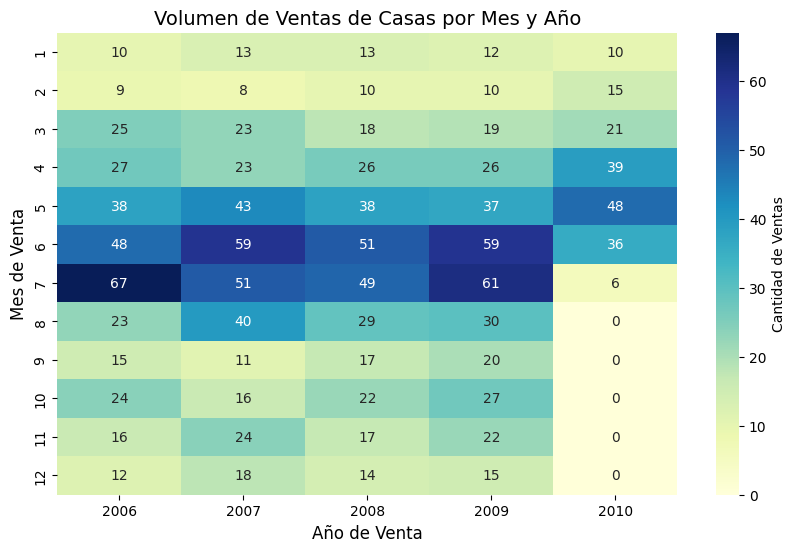

In [24]:
ventas_por_mes_año = pd.crosstab(index=train['MoSold'], columns=train['YrSold'])
plt.figure(figsize=(10, 6))

sns.heatmap(ventas_por_mes_año,annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Cantidad de Ventas'})

plt.title('Volumen de Ventas de Casas por Mes y Año', fontsize=14)
plt.xlabel('Año de Venta', fontsize=12)
plt.ylabel('Mes de Venta', fontsize=12)
plt.show()

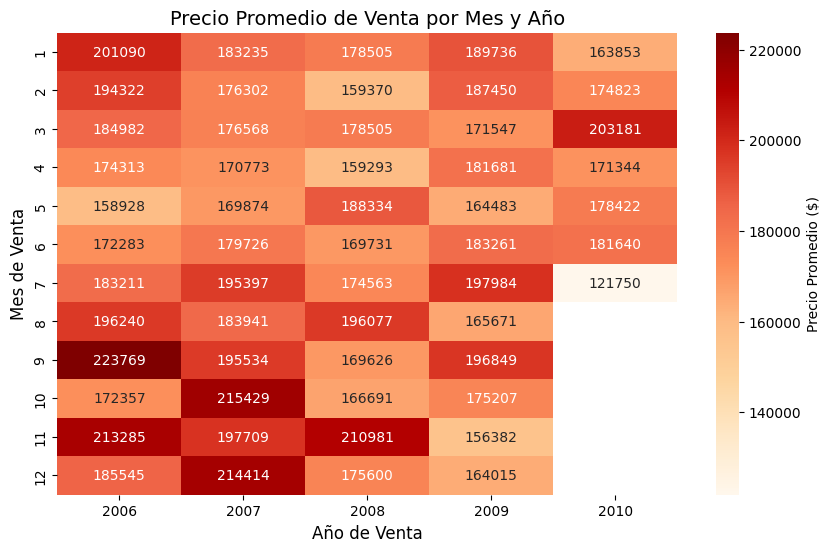

In [25]:
precio_por_mes_año = train.pivot_table(values='SalePrice', index='MoSold', columns='YrSold', aggfunc='mean')
plt.figure(figsize=(10, 6))

# 3. Dibujar el heatmap
sns.heatmap(precio_por_mes_año, annot=True, fmt='.0f', cmap='OrRd', cbar_kws={'label': 'Precio Promedio ($)'})

plt.title('Precio Promedio de Venta por Mes y Año', fontsize=14)
plt.xlabel('Año de Venta', fontsize=12)
plt.ylabel('Mes de Venta', fontsize=12)
plt.show()

#### Relación entre el Tamaño del Terreno y el Precio de Venta

Para analizar el impacto de las dimensiones de la propiedad en su valor de mercado, generamos un gráfico de dispersión (*scatterplot*) que cruza la superficie del lote (`LotArea`) con el precio de venta (`SalePrice`).

Este análisis visual nos permite:
* **Detectar la tendencia:** Observar si un mayor tamaño de terreno se traduce consistentemente en un precio más alto o si el valor se estabiliza a partir de cierta superficie.
* **Identificar valores atípicos (*outliers*):** Localizar propiedades con terrenos extremadamente grandes pero precios bajos (o viceversa), lo cual podría distorsionar los modelos predictivos.

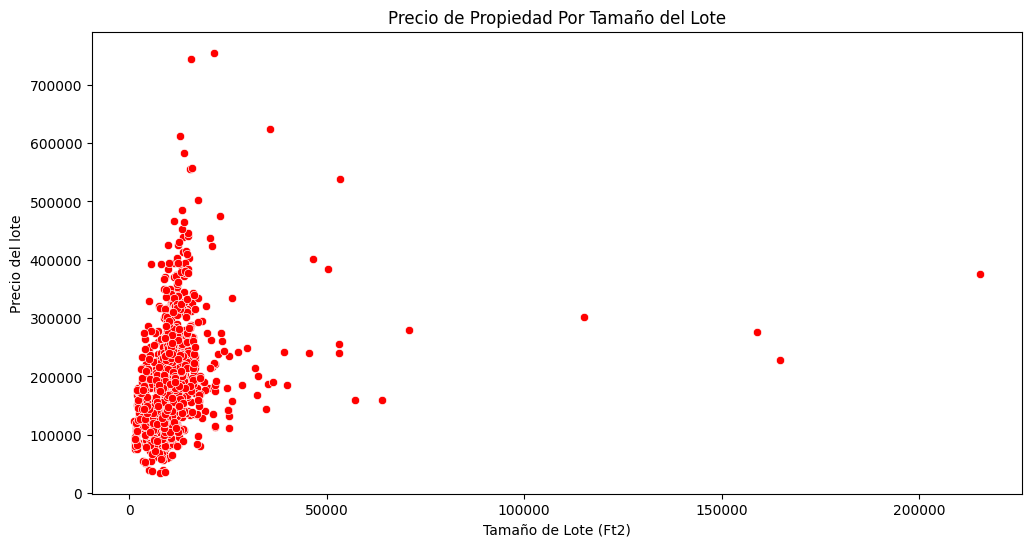

In [26]:
#Tamaño del terreno
plt.figure(figsize=(12,6))
sns.scatterplot(x='LotArea', y='SalePrice', data=train, color='red')
plt.xlabel('Tamaño de Lote (Ft2)')
plt.ylabel('Precio del lote')
plt.title('Precio de Propiedad Por Tamaño del Lote')
plt.show()

#### Tamaño Promedio del Terreno por Barrio (Neighborhood)

Dado que la ubicación es uno de los factores más determinantes en el mercado inmobiliario, en este apartado agrupamos los datos para calcular y comparar el tamaño promedio del lote (`LotArea`) en cada uno de los diferentes vecindarios (`Neighborhood`).

A través de este gráfico de barras podemos analizar:
* **Características de las zonas:** Identificar qué barrios se caracterizan por tener propiedades con terrenos más amplios (posiblemente zonas residenciales o periféricas) y cuáles tienen lotes más compactos (zonas urbanas o de alta densidad).
* **Contexto para el precio:** Este análisis nos ayuda a entender si los precios más altos en ciertos barrios se deben puramente a su ubicación de prestigio o si también están respaldados por una mayor cantidad de metros cuadrados/pies cuadrados de terreno.

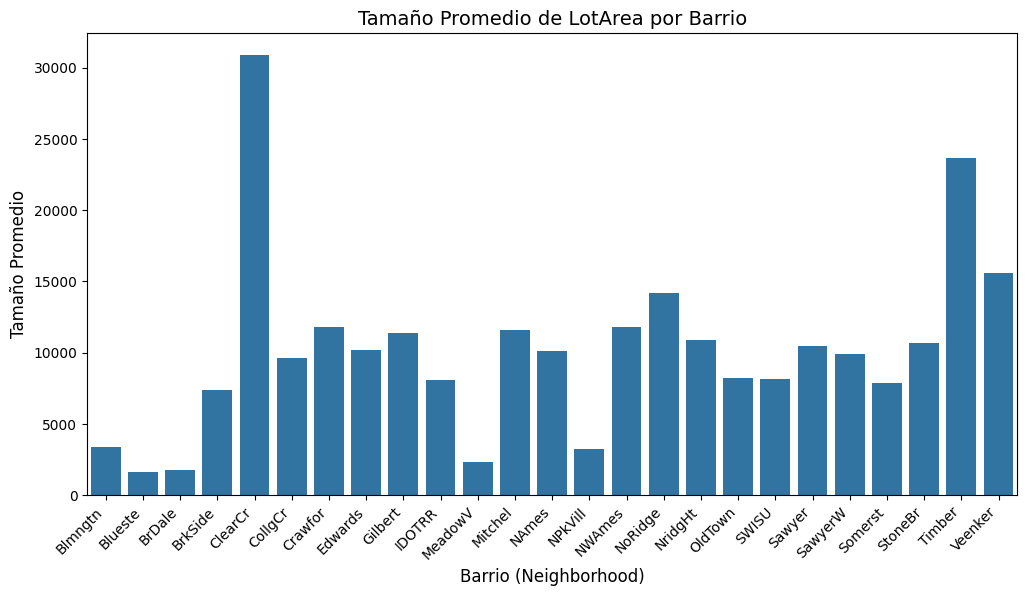

In [27]:
#Tamaño por barrio
tamaño_por_barrio = train.groupby('Neighborhood').agg(
    tamaño_promedio = ('LotArea', 'mean'),
).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Neighborhood', y='tamaño_promedio', data=tamaño_por_barrio)
plt.xticks(rotation=45, ha='right')
plt.title('Tamaño Promedio de LotArea por Barrio', fontsize=14)
plt.xlabel('Barrio (Neighborhood)', fontsize=12)
plt.ylabel('Tamaño Promedio', fontsize=12)

plt.show()

#### Precio Promedio por Pie Cuadrado ($ft^2$) por Barrio

Para obtener una métrica de valor más justa y estandarizada entre las distintas zonas, creamos una nueva variable que calcula el precio por pie cuadrado para cada propiedad ($\text{SalePrice} / \text{LotArea}$). Luego, agrupamos los datos para visualizar el costo promedio de esta unidad de medida en cada vecindario (`Neighborhood`).

Este enfoque nos permite:
* **Evaluar el valor real del suelo:** A diferencia del precio total de venta (que puede estar inflado simplemente porque la casa es enorme), el precio por $ft^2$ nos revela qué barrios son genuinamente los más caros y cotizados por unidad de superficie.
* **Descubrir asimetrías:** Identificar vecindarios donde el terreno es escaso y costoso, en contraste con zonas donde se pueden adquirir lotes más grandes a un menor costo relativo.

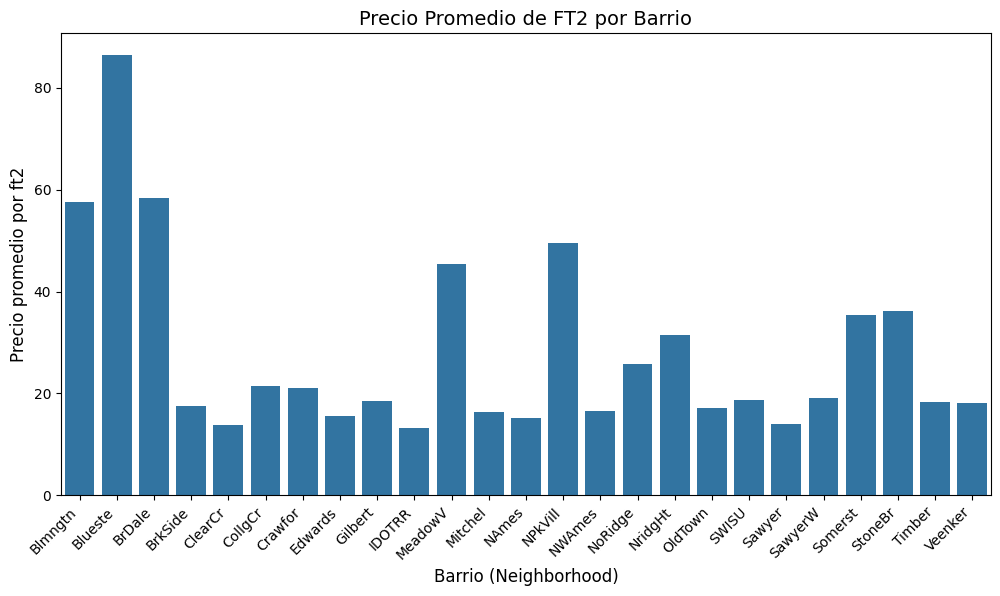

In [28]:
#Precio por ft2 por barrio

precio_por_ft2 = train[['Neighborhood', 'LotArea', 'SalePrice']].copy()
precio_por_ft2['precio_por_ft2'] = precio_por_ft2['SalePrice'] / precio_por_ft2['LotArea']

precio = precio_por_ft2.groupby('Neighborhood')['precio_por_ft2'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Neighborhood', y='precio_por_ft2', data = precio)
plt.xticks(rotation=45, ha='right')
plt.title('Precio Promedio de FT2 por Barrio', fontsize=14)
plt.xlabel('Barrio (Neighborhood)', fontsize=12)
plt.ylabel('Precio promedio por ft2', fontsize=12)

plt.show()

In [29]:
#condicion de estado de las casa por barrio

condicion = train.groupby('Neighborhood').agg(
    condicion_promedio = ('OverallCond', 'mean'),
    condicion_maxima = ('OverallCond', 'max'),
    condicion_minima = ('OverallCond', 'min'),
).reset_index().sort_values(by='condicion_promedio', ascending=False)
condicion

,Neighborhood,condicion_promedio,condicion_maxima,condicion_minima
6,Crawfor,6.588235,9,3
17,OldTown,6.353982,9,2
24,Veenker,6.272727,8,5
3,BrkSide,6.137931,9,2
1,Blueste,6.000000,6,6
14,NWAmes,5.945205,9,5
18,SWISU,5.920000,9,3
19,Sawyer,5.810811,9,3
12,NAmes,5.791111,9,3
4,ClearCr,5.678571,8,4


In [30]:
#precio promedio por condicion de estado

condicion_precio = train.groupby('OverallCond').agg(
    precio_promedio = ('SalePrice', 'mean'),
    precio_maximo = ('SalePrice', 'max'),
    precio_minimo = ('SalePrice', 'min')
).reset_index().sort_values(by='OverallCond', ascending = False)

condicion_precio

,OverallCond,precio_promedio,precio_maximo,precio_minimo
8,9,216004.545455,475000,110500
7,8,155651.736111,335000,84500
6,7,158145.487805,402000,79900
5,6,153961.591270,755000,37900
4,5,203146.914738,745000,34900
3,4,120438.438596,235000,40000
2,3,101929.400000,200624,35311
1,2,141986.400000,394432,67000
0,1,61000.000000,61000,61000


In [31]:
#condicion de calidad
calidad = train.groupby('OverallQual').agg(
     precio_promedio = ('SalePrice', 'mean'),
    precio_maximo = ('SalePrice', 'max'),
    precio_minimo = ('SalePrice', 'min')
    ).reset_index().sort_values(by='OverallQual', ascending = False)
calidad

,OverallQual,precio_promedio,precio_maximo,precio_minimo
9,10,438588.388889,755000,160000
8,9,367513.023256,611657,239000
7,8,274735.535714,538000,122000
6,7,207716.423197,383970,82500
5,6,161603.034759,277000,76000
4,5,133523.347607,228950,55993
3,4,108420.655172,256000,34900
2,3,87473.750000,139600,37900
1,2,51770.333333,60000,35311
0,1,50150.000000,61000,39300


In [32]:
#condicion de calidad de las casa por barrio

condicion = train.groupby('Neighborhood').agg(
    condicion_promedio = ('OverallQual', 'mean'),
    condicion_maxima = ('OverallQual', 'max'),
    condicion_minima = ('OverallQual', 'min'),
).reset_index().sort_values(by='condicion_promedio', ascending=False)
condicion

,Neighborhood,condicion_promedio,condicion_maxima,condicion_minima
16,NridgHt,8.259740,10,6
22,StoneBr,8.160000,10,7
15,NoRidge,7.926829,10,7
21,Somerst,7.337209,10,6
0,Blmngtn,7.176471,8,7
23,Timber,7.157895,9,5
24,Veenker,6.727273,9,5
5,CollgCr,6.640000,9,4
8,Gilbert,6.556962,9,4
14,NWAmes,6.328767,8,5


#Outliers

##Tamaño de Area

#### Detección de Valores Atípicos (Outliers) en el Tamaño del Terreno

Utilizamos un gráfico de dispersión (*scatterplot*) de rango amplio para examinar los extremos de la variable `LotArea` en relación con el `SalePrice`. El objetivo principal de este gráfico es localizar **anomalías en los datos** que puedan perjudicar el entrenamiento de nuestros modelos predictivos.

En el mercado inmobiliario, es crucial identificar dos tipos de comportamiento atípico:
* **Terrenos gigantes a precios muy bajos:** Propiedades con un `LotArea` inmenso pero un precio plano o bajo. Estos puntos suelen representar terrenos agrícolas, rurales o datos con errores de registro que rompen la tendencia general.
* **Casas ultra-premium:** Propiedades con terrenos estándar pero precios extremadamente elevados debido a su lujo o construcción.

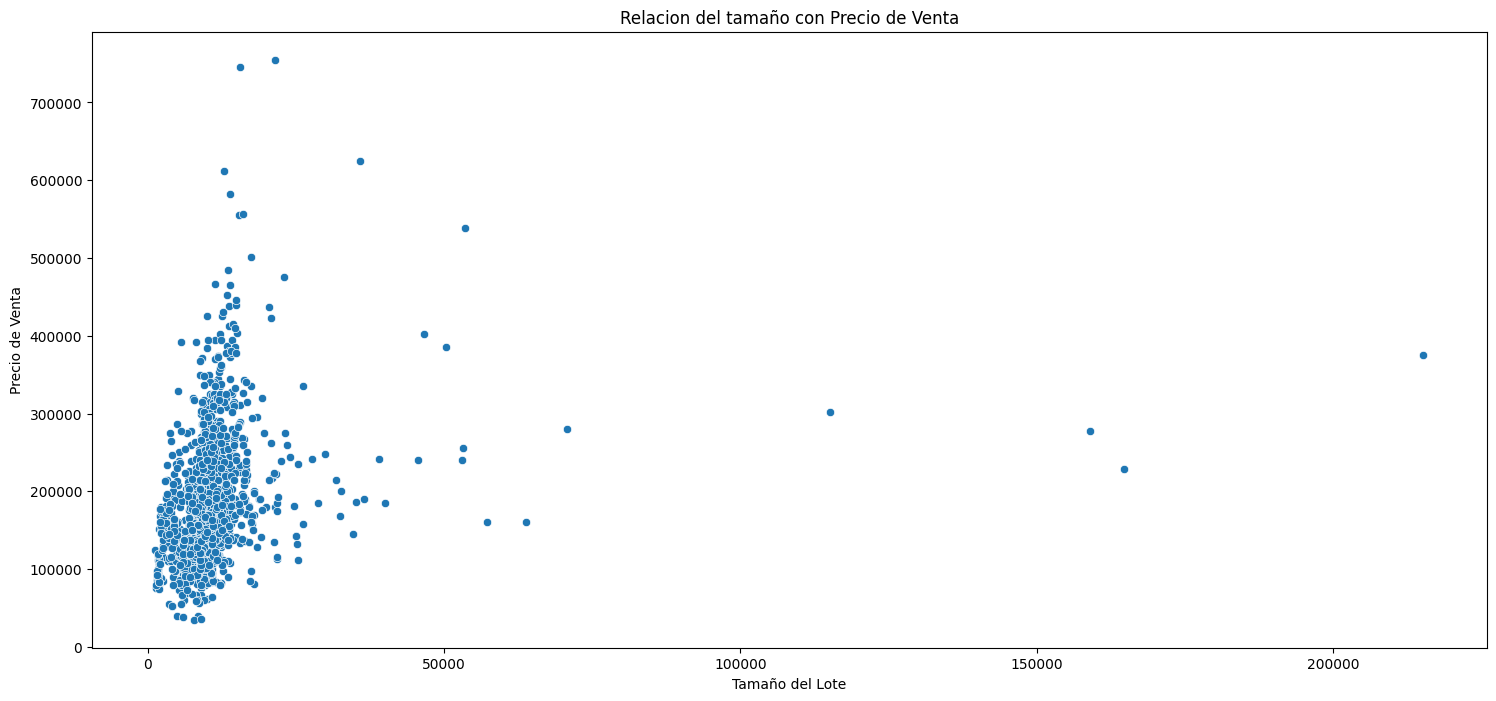

In [33]:
#Buscamos los outliers que tengan terrenos muy grandes
frente = train[['LotArea', 'SalePrice']]

plt.figure(figsize=(18,8))
sns.scatterplot(x='LotArea', y='SalePrice', data=frente)
plt.xlabel('Tamaño del Lote')
plt.ylabel('Precio de Venta')
plt.title('Relacion del tamaño con Precio de Venta')
plt.show()

In [34]:
#me quedo con los que estan por arriba del limite superior
limite_superior = train['LotArea'].quantile(0.9975)
train[train['LotArea'] >= limite_superior]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,None,IR2,Low,AllPub,...,0,None,None,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,None,IR3,Low,AllPub,...,0,None,None,None,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,None,IR1,HLS,AllPub,...,0,None,None,Shed,700,8,2008,WD,Normal,228950
706,707,20,RL,NaN,115149,Pave,None,IR2,Low,AllPub,...,0,None,None,None,0,6,2007,WD,Normal,302000


In [35]:
#Borro las que estan por arriba del limite superior
train = train[train['LotArea'] <= limite_superior]
train[train['LotArea'] <= limite_superior]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


##Tamaño de construccion


####Detección de Outliers por Superficie Total Construida

En este análisis vamos un paso más allá de la superficie del terreno y evaluamos el tamaño real de la edificación. Para ello, creamos una nueva variable temporal llamada `total_construido`, la cual suma la superficie total del sótano (`TotalBsmtSF`) con el área habitable sobre el nivel del suelo (`GrLivArea`).

Cruzando esta nueva métrica con el `SalePrice` en un gráfico de dispersión, buscamos identificar anomalías críticas:

* **La regla general:** Esperamos ver una relación lineal muy fuerte y limpia; a mayor cantidad de pies cuadrados cubiertos/construidos, mayor es el precio de la propiedad.
* **El objetivo de la búsqueda:** Identificar casos específicos donde esta regla se rompe drásticamente. En particular, buscamos propiedades con un `total_construido` descomunal (por ejemplo, más de $4,000\text{ o }5,000\text{ ft}^2$) pero con precios de venta llamativamente bajos.

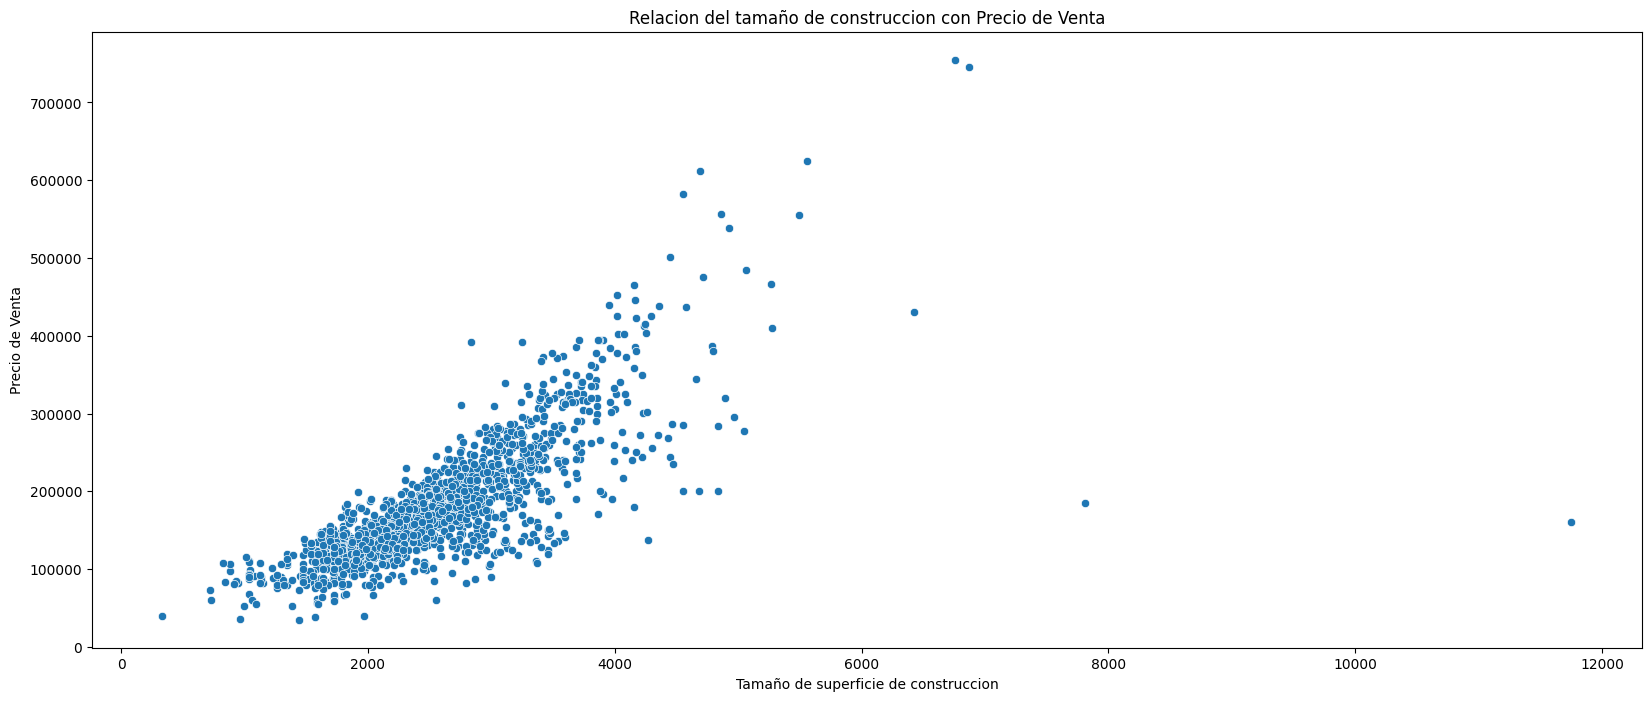

In [36]:
#Buscamos los outliers que tengan construcciones muy grandes sumando construccion total y sotano
frente = train[['TotalBsmtSF', 'SalePrice', 'GrLivArea']].copy()

frente['total_construido'] = frente['TotalBsmtSF'] + frente['GrLivArea']
plt.figure(figsize=(20,8))
sns.scatterplot(x='total_construido', y='SalePrice', data=frente)
plt.xlabel('Tamaño de superficie de construccion')
plt.ylabel('Precio de Venta')
plt.title('Relacion del tamaño de construccion con Precio de Venta')
plt.show()

In [37]:
#propiedades con la mayor superficie de construccion habitables, pero con precios bajos
limite = frente['total_construido'].quantile(0.99)
limite_precio = frente[frente['total_construido'] >= limite]['SalePrice'].quantile(0.1)
construccion_outlier = frente[(frente['total_construido'] >= limite) & (frente['SalePrice'] <= limite_precio)]
construccion_outlier

,TotalBsmtSF,SalePrice,GrLivArea,total_construido
523,3138,184750,4676,7814
1298,6110,160000,5642,11752


In [38]:
train = train.drop(construccion_outlier.index)

##Total de Habitaciones

####Análisis de Precios por Cantidad de Habitaciones Totales

Para investigar cómo influye el número de habitaciones en el valor de la propiedad y detectar anomalías, agrupamos los datos según la cantidad de habitaciones totales sobre el nivel del suelo (`TotRmsAbvGrd`). Calculamos el precio medio, máximo y mínimo para cada grupo.

A partir de la tabla obtenida, podemos extraer las siguientes observaciones clave:
* **Tendencia General:** Como es de esperarse, el precio promedio de las viviendas mantiene una relación directa y ascendente con la cantidad de habitaciones; a mayor número de cuartos, el valor de la propiedad tiende a subir.
* **Comportamiento Anómalo (A partir de 11 y 12 habitaciones):** * **El caso de las 11 habitaciones:** Se observa un precio mínimo inusualmente bajo que rompe con la tendencia del grupo, lo que sugiere la presencia de una propiedad con muchas habitaciones pero un valor de mercado muy devaluado (posible *outlier*).
    * **El quiebre en las 12 habitaciones:** Al llegar a este punto, el promedio de precio deja de subir de forma natural y muestra un comportamiento extraño o plano, lo cual amerita una revisión detallada de esos registros específicos.

In [39]:
#Buscamos los outliers que tengan muchas habitaciones pero precios bajos

cant_habitaciones = train.groupby('TotRmsAbvGrd').agg(
    precio_medio = ('SalePrice', 'mean'),
    precio_maximo = ('SalePrice', 'max'),
    precio_minimo = ('SalePrice', 'min'),
)
cant_habitaciones

#el promedio del precio aumenta con la cantidad de habitaciones, hasta que llega el 12 y ahi es raro, tambien ver el minimo de 11 habitaciones

,precio_medio,precio_maximo,precio_minimo
TotRmsAbvGrd,,,
2,39300.000000,39300,39300
3,111217.647059,155900,60000
4,122844.628866,260000,34900
5,140965.167883,392500,52000
6,161303.296020,374000,37900
7,196322.391437,465000,55000
8,212558.860215,466500,81000
9,252988.173333,501837,98000
10,296279.170213,755000,90000


In [40]:
propiedades = train[train['TotRmsAbvGrd'] >= 11].sort_values(by=['TotRmsAbvGrd', 'SalePrice'], ascending=[False, True])
propiedades['precio_por_habitacion'] = propiedades['SalePrice'] / propiedades['TotRmsAbvGrd']
propiedades[['SalePrice', 'precio_por_habitacion', 'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'LotArea', 'SaleType', 'SaleCondition', 'GarageCars', 'YearBuilt', 'Id']]


,SalePrice,precio_por_habitacion,TotRmsAbvGrd,OverallQual,OverallCond,LotArea,SaleType,SaleCondition,GarageCars,YearBuilt,Id
635,200000,14285.714286,14,6,7,10896,WD,Abnorml,0,1914,636
897,142953,11912.750000,12,5,5,7018,WD,Alloca,2,1979,898
910,154300,12858.333333,12,5,5,11600,WD,Normal,2,1960,911
1230,190000,15833.333333,12,5,5,18890,WD,Normal,2,1977,1231
1031,197000,16416.666667,12,7,3,15863,WD,Normal,2,1920,1032
1350,200000,16666.666667,12,5,5,11643,WD,Normal,4,1969,1351
1173,200500,16708.333333,12,5,6,18030,WD,Normal,0,1946,1174
1386,250000,20833.333333,12,7,5,16692,WD,Normal,2,1978,1387
185,475000,39583.333333,12,10,9,22950,WD,Normal,3,1892,186
769,538000,44833.333333,12,8,5,53504,WD,Normal,3,2003,770


In [41]:
#condifiocnes de venta raros y precios raros para esas casas
outliers = train[(train['Id'] == 636) | (train['Id'] == 898)]
outliers
train.drop(outliers.index)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


#Rellenar datos faltantes

#### 🔍 Verificación Final de Valores Nulos Restantes

Para dar por concluida la etapa de preparación de datos, realizamos un conteo final de valores nulos (`isnull().sum()`) de forma simultánea en los conjuntos de entrenamiento (`train`) y prueba (`test`).

Al inspeccionar los resultados, detectamos que el set de **test** presenta pequeñas pérdidas de datos en variables que en **train** estaban completas. El diagnóstico y la estrategia de resolución para estos últimos faltantes se detallan a continuación:

* **`LotFrontage` (256 en train / 227 en test):** Sigue siendo la variable con mayor ausencia de datos en ambos conjuntos. Un número considerable de propiedades no cuenta con el registro de los pies lineales de fachada. Se resolverá mediante una imputación avanzada (como la mediana según el barrio).
* **`MSZoning` (4 en test) y `Functional` (2 en test):** Un grupo mínimo de registros en el set de prueba carece de la clasificación zonal y de la funcionalidad de la vivienda. Al ser tan pocos casos, se imputarán utilizando la moda (el valor más frecuente) de cada columna en `train`.
* **`Electrical` (1 en train), `Exterior1st` (1 en test), `KitchenQual` (1 en test) y `SaleType` (1 en test):** Presentan apenas un único valor nulo aislado. Se solucionarán rápidamente imputándolos con la moda del set de entrenamiento (por ejemplo, `SBrkr` para el sistema eléctrico o `TA` para la calidad de la cocina).
* **`TotalBsmtSF`, `BsmtFullBath` (2 en test) y `BsmtHalfBath` (2 en test):** El set de prueba arroja la ausencia de datos en el total de la superficie del sótano y en el conteo de sus baños. Estos casos corresponden a viviendas que directamente **no poseen sótano**, por lo que se imputarán con `0`.
* **`GarageArea` (1 en test):** Una única propiedad en el set de prueba no registra la superficie del estacionamiento, coincidiendo con la ausencia física de un garaje, por lo que se completará con `0`.

In [42]:
columnas_vacias = train.isnull().sum()
columnas_vacias[columnas_vacias > 0]
#hay 256 casas que no tienen informacion de lotFrontagte y 1 que no tiene informacion de electrical

,0
LotFrontage,256
Electrical,1


In [43]:
columnas_vacias = test.isnull().sum()
columnas_vacias[columnas_vacias > 0]

,0
MSZoning,4
LotFrontage,227
Utilities,2
Exterior1st,1
Exterior2nd,1
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1
BsmtFullBath,2


##Bsmt

In [44]:
test[test['BsmtFinSF1'].isnull() | test['BsmtFinSF2'].isnull() |test['BsmtUnfSF'].isnull()| test['TotalBsmtSF'].isnull()|test['BsmtFullBath'].isnull()|test['BsmtHalfBath'].isnull()][['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtQual']]

,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath,BsmtQual
660,NaN,NaN,NaN,NaN,NaN,NaN,None
728,0.0,0.0,0.0,0.0,NaN,NaN,None


In [45]:
columnas = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
test[columnas] = test[columnas].fillna(0)

##SaleType

In [46]:
mapa_sale = train.groupby('SaleCondition')['SaleType'].describe()['top']

test['SaleType'] = test['SaleType'].fillna(test['SaleCondition'].map(mapa_sale))
test['SaleType'] = test['SaleType'].fillna(train['SaleType'].describe()['top'])

##Garage

In [47]:
mapa_cars_doble = train.groupby(['Neighborhood', 'GarageType'])['GarageCars'].median()
mapa_cars_barrio = train.groupby('Neighborhood')['GarageCars'].median()

test['GarageCars'] = test['GarageCars'].fillna(
    pd.Series(test.set_index(['Neighborhood', 'GarageType']).index.map(mapa_cars_doble).values, index=test.index)
)
test['GarageCars'] = test['GarageCars'].fillna(test['Neighborhood'].map(mapa_cars_barrio))
test['GarageCars'] = test['GarageCars'].fillna(train['GarageCars'].median())

In [48]:
mapa_area_por_autos = train.groupby('GarageCars')['GarageArea'].median()

test['GarageArea'] = test['GarageArea'].fillna(test['GarageCars'].map(mapa_area_por_autos))
test['GarageArea'] = test['GarageArea'].fillna(train['GarageArea'].median())

##KitchenQual

In [49]:
mapa_cocina = train.groupby('OverallQual')['KitchenQual'].describe()['top']

test['KitchenQual'] = test['KitchenQual'].fillna(test['OverallQual'].map(mapa_cocina))
test['KitchenQual'] = test['KitchenQual'].fillna(train['KitchenQual'].describe()['top'])

##Baños

In [50]:
limites = [-1, 0, 500, 1000, 1500, 5000]
etiquetas = ['Sin_Terminar_o_Cero', 'Pequeño', 'Mediano', 'Grande', 'Mansión']

train_rangos_sf = pd.cut(train['BsmtFinSF1'], bins=limites, labels=etiquetas)
test_rangos_sf = pd.cut(test['BsmtFinSF1'], bins=limites, labels=etiquetas)

mapa_full_bath = train.groupby(train_rangos_sf, observed=False)['BsmtFullBath'].median()

test['BsmtFullBath'] = test['BsmtFullBath'].fillna(test_rangos_sf.map(mapa_full_bath))
test['BsmtFullBath'] = test['BsmtFullBath'].fillna(train['BsmtFullBath'].median())

In [51]:
mapa_half_bath = train.groupby('BsmtFullBath')['BsmtHalfBath'].median()

test['BsmtHalfBath'] = test['BsmtHalfBath'].fillna(test['BsmtFullBath'].map(mapa_half_bath))


test['BsmtHalfBath'] = test['BsmtHalfBath'].fillna(0)

##Functional

In [52]:
mapa_funcionalidad = train.groupby('OverallCond')['Functional'].describe()['top']

test['Functional'] = test['Functional'].fillna(test['OverallCond'].map(mapa_funcionalidad))
test['Functional'] = test['Functional'].fillna(train['Functional'].describe()['top'])

##Electricidad

####Análisis e Imputación de la Variable 'Electrical'

Para resolver el único valor nulo detectado en la variable `Electrical`, decidimos no imputar a ciegas. En su lugar, aplicamos una estrategia de **imputación basada en vecindad y similitud**:

1. **Aislamiento del caso:** Identificamos la propiedad afectada y extrajimos su perfil utilizando el tipo de vivienda (`MSSubClass`) y su clasificación de zona (`MSZoning`).
2. **Búsqueda de pares:** Filtramos el dataset para observar qué tipo de sistema eléctrico poseen las casas que comparten exactamente estas mismas características estructurales y de ubicación.
3. **Hallazgo:** El análisis reveló que la abrumadora mayoría (el 99%) de las viviendas similares utilizan el sistema `SBrkr`.

In [53]:
#como se comporta la variable electrical
train['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [54]:

train[train['Electrical'].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2008,WD,Normal,167500


In [55]:
#veamos las casas de ese estilo que electricidad tienen
casa_sin_electricidad = train[train['Electrical'].isnull()].iloc[0]
casas_parecidas = train[(train['MSSubClass'] == casa_sin_electricidad['MSSubClass']) & (train['MSZoning'] == casa_sin_electricidad['MSZoning'])]
casas_parecidas['Electrical']

#uso la clasificacion de la casa y la clasificacion de la zona para ver que electricidad tienen

#el 99% es SBrkr lo agrego a esa



,Electrical
54,SBrkr
84,SBrkr
111,SBrkr
120,SBrkr
186,SBrkr
253,SBrkr
260,SBrkr
262,SBrkr
295,SBrkr
319,SBrkr


In [56]:
#le cambio el valor
train.loc[train['Id'] == casa_sin_electricidad['Id'], 'Electrical'] = 'SBrkr'

train[train['Id'] == casa_sin_electricidad['Id']]['Electrical']

,Electrical
1379,SBrkr


##LotFrontage

#### Análisis Avanzado e Imputación Estratégica de 'LotFrontage'

La variable `LotFrontage` (pies lineales de calle conectados a la propiedad) presenta 256 valores nulos. Para resolver esto, evitamos una imputación simple por la media global y realizamos un análisis de dependencias físicas y geográficas:

1. **Descarte de variables irrelevantes:** Se determinó que el precio de venta o el año de construcción no aportan información real sobre la estructura física del terreno. Tampoco la forma geométrica (`LotShape`) o el tipo de casa, ya que terrenos amplios pueden albergar construcciones simples.
2. **Evaluación de correlaciones:** Mediante un gráfico de dispersión, confirmamos que existe una relación directa entre el tamaño total del terreno (`LotArea`) y su frente (`LotFrontage`), detectando además un par de *outliers* claros en los extremos.
3. **Criterio de Agrupación Espacial:** La ubicación (`Neighborhood`) es el factor clave, ya que los loteos en un mismo barrio siguen patrones de diseño similares. A esto le sumamos la configuración del lote (`LotConfig`), que define si la propiedad está en una esquina, en una calle sin salida (*Cul-de-sac*), etc., lo cual altera drásticamente los pies de calle disponibles.

> **Estrategia de Imputación en Cascada (Fallback):**
> * **Paso 1:** Imputamos los valores nulos utilizando la **mediana** combinada de su vecindario y su configuración de lote (`['Neighborhood', 'LotConfig']`).
> * **Paso 2:** Como resguardo para casos excepcionales (por ejemplo, si una casa tiene una combinación de `LotConfig` única en su barrio y el paso anterior devuelve nulo), aplicamos una segunda imputación utilizando únicamente la mediana general del barrio (`'Neighborhood'`).

Con esta combinación de criterios geográficos y estructurales, logramos restaurar los datos faltantes reflejando la realidad urbanística de cada propiedad de forma sumamente precisa.

In [57]:
#como se comporta la columna
#LotFrontage = Pies lineales de calle conectados a la propiedad. (Numérico)
train['LotFrontage'].unique()

#numeros, no hay taaaanta cantidad pero pueden ser distintos

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  33.,  52., 100.,  24.,  89.,  63.,  76.,
        81.,  95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,
        77.,  64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,
        92., 134.,  62.,  86., 141.,  97.,  54.,  41.,  79., 174.,  99.,
        67.,  83.,  43., 103.,  93.,  30., 129., 140.,  35.,  37., 118.,
        87., 116., 111.,  49.,  96.,  59.,  36.,  56., 102.,  58.,  38.,
       109., 130.,  53., 137.,  45., 106., 104.,  42.,  39., 144., 114.,
       128., 149., 313., 168., 182., 138., 160., 152., 124., 153.,  46.])

In [58]:
train[train['LotFrontage'].isnull()]
#256 propiedades sin LotFrontage

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
7,8,60,RL,NaN,10382,Pave,None,IR1,Lvl,AllPub,...,0,None,None,Shed,350,11,2009,WD,Normal,200000
12,13,20,RL,NaN,12968,Pave,None,IR2,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,144000
14,15,20,RL,NaN,10920,Pave,None,IR1,Lvl,AllPub,...,0,None,GdWo,None,0,5,2008,WD,Normal,157000
16,17,20,RL,NaN,11241,Pave,None,IR1,Lvl,AllPub,...,0,None,None,Shed,700,3,2010,WD,Normal,149000
24,25,20,RL,NaN,8246,Pave,None,IR1,Lvl,AllPub,...,0,None,MnPrv,None,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,1430,20,RL,NaN,12546,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,4,2007,WD,Normal,182900
1431,1432,120,RL,NaN,4928,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,10,2009,WD,Normal,143750
1441,1442,120,RM,NaN,4426,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2008,WD,Normal,149300
1443,1444,30,RL,NaN,8854,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2009,WD,Normal,121000


In [59]:
#que variables pueden ayudar a mejorar que valor poner, me interesa el valor de venta? o el valor del año? No, necesito variables relacionadas al terreno, zonas, etc
#veamos como actua la variable lotfrontage segun distintas agrupaciones de menos a mas

In [60]:
frente_barrio = train.groupby('Neighborhood')['LotFrontage'].median().reset_index()
frente_barrio
#barrios con terrenos y casas relacionadas

,Neighborhood,LotFrontage
0,Blmngtn,43.0
1,Blueste,24.0
2,BrDale,21.0
3,BrkSide,52.0
4,ClearCr,80.0
5,CollgCr,70.0
6,Crawfor,74.0
7,Edwards,64.5
8,Gilbert,65.0
9,IDOTRR,60.0


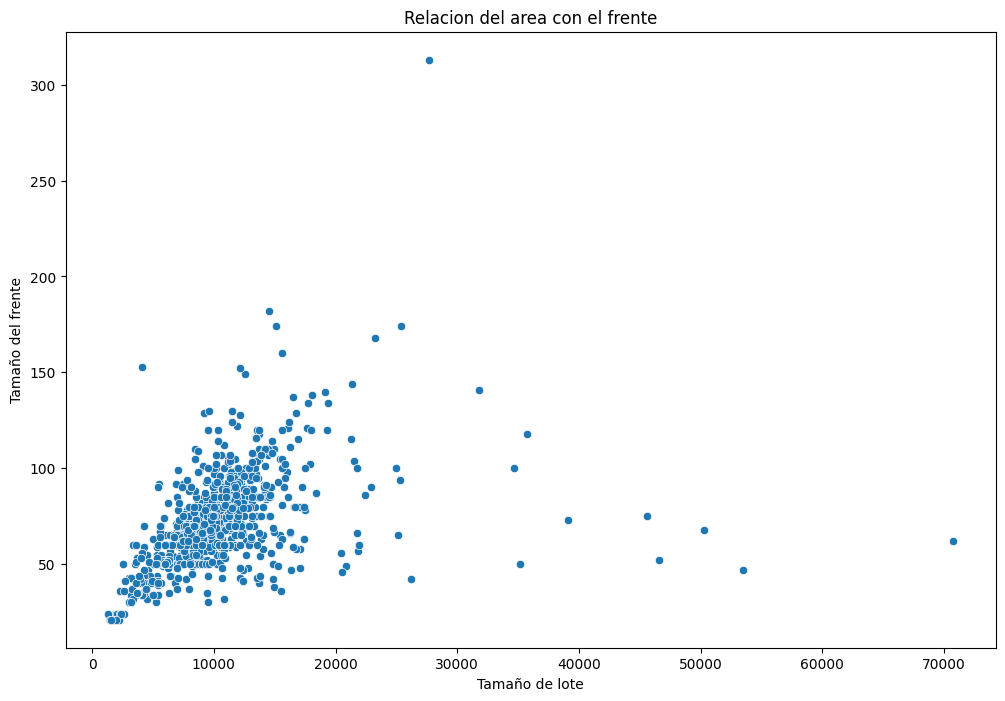

In [61]:
#tamaño de terreno y frente

plt.figure(figsize=(12,8))
sns.scatterplot(x='LotArea', y='LotFrontage', data=train)
plt.xlabel('Tamaño de lote')
plt.ylabel('Tamaño del frente')
plt.title('Relacion del area con el frente')
plt.show()

#2 outliers claros

In [62]:
train[['LotArea', 'LotFrontage']].corr()

,LotArea,LotFrontage
LotArea,1.000000,0.489505
LotFrontage,0.489505,1.000000


In [63]:
limite_terreno = train['LotArea'].quantile(0.99999)
limite_frente = train['LotFrontage'].quantile(0.9999)

train[(train['LotArea'] >= limite_terreno) | (train['LotFrontage'] >= limite_frente)][['MSSubClass', 'MSZoning', 'Neighborhood','LotFrontage', 'LotArea', 'LotShape', 'LotConfig', 'SalePrice']]

#20: 1 piso, construida en 1946 o más nueva, todos los estilos.
#RL: Residencial de baja densidad.
# IR1: Ligeramente irregular; IR2: Moderadamente irregular
#Inside: Terreno interior

#comparte casi todo son muy parecidas pero son contrarias en 2 cosas, el area del terreno y el frente

,MSSubClass,MSZoning,Neighborhood,LotFrontage,LotArea,LotShape,LotConfig,SalePrice
451,20,RL,ClearCr,62.0,70761,IR1,Inside,280000
934,20,RL,NAmes,313.0,27650,IR2,Inside,242000


In [64]:
train.groupby('LotConfig')['LotFrontage'].median()


,LotFrontage
LotConfig,
Corner,80.0
CulDSac,50.0
FR2,64.0
FR3,59.5
Inside,67.5


In [65]:
train.groupby('LotShape')['LotFrontage'].median()


,LotFrontage
LotShape,
IR1,73.5
IR2,57.5
IR3,66.0
Reg,67.0


In [66]:
#algunas variables estan relacionadas, tipo de zona esta relacionada con el barrio, agrupar por barrio y mszoning no vale la pena
#tipo de casa tambien no me importa, puede ser un terreno con frente pero unba casa simple
#me quedo con los barrios, tiene cierta relacion entre las casas
#tambien me quedo con lotconfig que es como esta el terreno, si en la esquina, calle sin salida, etc
#LotShape es la forma geometrica del terreno, pero la mayoria es Reg o IR1, no me va a decir mucho

In [67]:
#agrupamos por mas
train.groupby(['Neighborhood', 'LotConfig'])['LotFrontage'].median().reset_index()

,Neighborhood,LotConfig,LotFrontage
0,Blmngtn,Inside,43.0
1,Blueste,Inside,24.0
2,BrDale,Inside,21.0
3,BrkSide,Corner,51.0
4,BrkSide,FR2,60.0
...,...,...,...
73,Timber,Inside,85.0
74,Veenker,Corner,90.0
75,Veenker,CulDSac,31.0
76,Veenker,FR2,80.0


In [68]:
#para rellenar los valores del lotfrontage, me fijo con el barrio y con el lotconfig, se que estan todos los datos para todas las casas.

medianas_lotfrontage = train.groupby(['Neighborhood', 'LotConfig'])['LotFrontage'].transform('median')
train['LotFrontage'] = train['LotFrontage'].fillna(medianas_lotfrontage)
#aglun caso raro que es el unico con lotconfig en el barrio, lo hago por barrio
medianas_solo_barrio = train.groupby('Neighborhood')['LotFrontage'].transform('median')
train['LotFrontage'] = train['LotFrontage'].fillna(medianas_solo_barrio)


In [69]:
medianas_lotfrontage_train = train.groupby(['Neighborhood', 'LotConfig'])['LotFrontage'].median()
medianas_solo_barrio_train = train.groupby(['Neighborhood'])['LotFrontage'].median()

test['LotFrontage'] = test['LotFrontage'].fillna(
    pd.Series(test.set_index(['Neighborhood', 'LotConfig']).index.map(medianas_lotfrontage_train).values, index=test.index)
)

#aglun caso raro que es el unico con lotconfig en el barrio, lo hago por barrio
test['LotFrontage'] = test['LotFrontage'].fillna(test['Neighborhood'].map(medianas_solo_barrio_train))

#caso mas extraño si no hay nada lo hace con la mediana general
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())

##MSZoning

In [70]:
#Uso la misma idea, agrupo por barrio y por el tipo de casa

In [71]:
mapa_zoning_doble = train.groupby(['Neighborhood', 'BldgType'])['MSZoning'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
mapa_zoning_barrio = train.groupby('Neighborhood')['MSZoning'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

test['MSZoning'] = test['MSZoning'].fillna(
    pd.Series(test.set_index(['Neighborhood', 'BldgType']).index.map(mapa_zoning_doble).values, index=test.index)
)

test['MSZoning'] = test['MSZoning'].fillna(test['Neighborhood'].map(mapa_zoning_barrio))

test['MSZoning'] = test['MSZoning'].fillna(train['MSZoning'].mode()[0])

##Exterior1st y Exterior2nd

In [72]:
mapa_exterior_doble = train.groupby(['Neighborhood', 'Exterior2nd'])['Exterior1st'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
mapa_exterior_barrio = train.groupby('Neighborhood')['Exterior1st'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

test['Exterior1st'] = test['Exterior1st'].fillna(
    pd.Series(test.set_index(['Neighborhood', 'Exterior2nd']).index.map(mapa_exterior_doble).values, index=test.index)
)

test['Exterior1st'] = test['Exterior1st'].fillna(test['Neighborhood'].map(mapa_exterior_barrio))

test['Exterior1st'] = test['Exterior1st'].fillna(train['Exterior1st'].mode()[0])

In [73]:
mapa_exterior_doble = train.groupby(['Neighborhood', 'Exterior1st'])['Exterior2nd'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
mapa_exterior_barrio = train.groupby('Neighborhood')['Exterior2nd'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

test['Exterior2nd'] = test['Exterior2nd'].fillna(
    pd.Series(test.set_index(['Neighborhood', 'Exterior1st']).index.map(mapa_exterior_doble).values, index=test.index)
)

test['Exterior2nd'] = test['Exterior2nd'].fillna(test['Neighborhood'].map(mapa_exterior_barrio))

test['Exterior2nd'] = test['Exterior2nd'].fillna(train['Exterior2nd'].mode()[0])

##Bsmt

In [74]:
test[test['TotalBsmtSF'].isnull()][['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']]

,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath


##Utilities

In [75]:
mapa_utilities_barrio = train.groupby('Neighborhood')['Utilities'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

test['Utilities'] = test['Utilities'].fillna(test['Neighborhood'].map(mapa_utilities_barrio))

test['Utilities'] = test['Utilities'].fillna(train['Utilities'].mode()[0])

#Feature Engineering

####Creación y Análisis de la Superficie Estructural Total (`TotalStructureSF`)

Para capturar el verdadero tamaño de toda la infraestructura construida en la propiedad (no solo la casa o el sótano), consolidamos una nueva métrica holística llamada `TotalStructureSF`. Esta variable unifica todas las áreas cubiertas, semicubiertas y descubiertas estructuradas de la vivienda sumando:

$$\text{TotalStructureSF} = \text{GrLivArea} + \text{GarageArea} + \text{TotalBsmtSF} + \text{Porches y Terrazas (WoodDeck, OpenPorch, EnclosedPorch, 3SsnPorch, ScreenPorch)}$$

Al cruzar esta nueva variable con el precio de venta (`SalePrice`) en un gráfico de dispersión, buscamos:
* **Evaluar la fuerza de la correlación:** Medir si la consolidación de todas las áreas exteriores (porches/terrazas) y anexos (garaje) genera una relación lineal aún más sólida y compacta con el precio que las variables individuales.
* **Control final de Outliers Estructurales:** Identificar si existen propiedades que, a pesar de tener una infraestructura total gigantesca (sumando terrazas y garajes), mantienen un precio sospechosamente bajo, lo que consolidaría su estatus de *outliers* para el modelo.

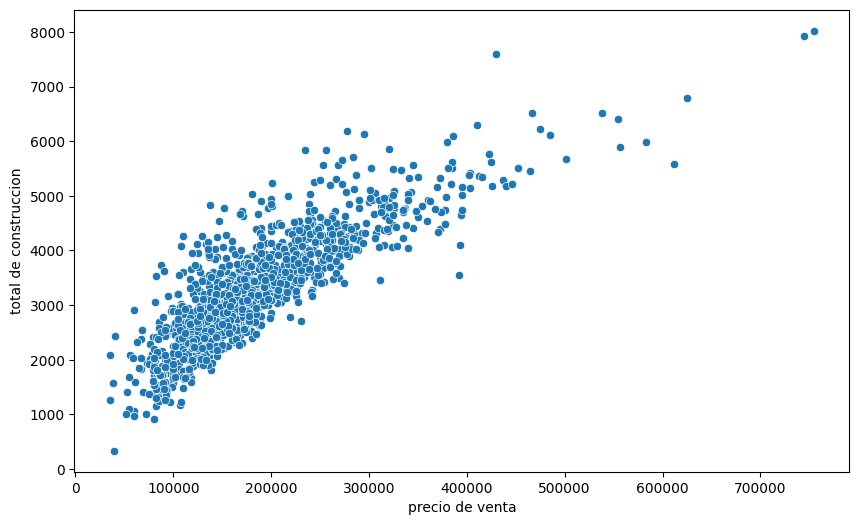

In [76]:
#Superficie total de construccion

df = train[['SalePrice', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].copy()

df['TotalStructureSF'] = (
    df['GrLivArea'] +
    df['GarageArea'] +
    df['TotalBsmtSF'] +
    df['WoodDeckSF'] +
    df['OpenPorchSF'] +
    df['EnclosedPorch'] +
    df['3SsnPorch'] +
    df['ScreenPorch']
)

plt.figure(figsize=(10,6))
sns.scatterplot(x='SalePrice', y='TotalStructureSF', data=df)
plt.xlabel('precio de venta')
plt.ylabel('total de construccion')
plt.show()

Consolidación de la Variable 'TotalSuperficieConstruida' en Train y Test

Tras validar visualmente la fuerte correlación lineal de esta métrica con el valor de las propiedades, procedemos a integrar formalmente la nueva variable `TotalSuperficieConstruida` tanto en el conjunto de entrenamiento (`train`) como en el de prueba (`test`).

Esta combinación matemática condensa 8 variables independientes de áreas en un único predictor de alto impacto, representando la superficie total construida (incluyendo áreas habitables, subterráneas, garajes, porches y terrazas).

In [77]:
#me sirve los valores, de la cantidad de metros construidos, lo copio en test y train creando las nuevas variables
train['TotalSuperficieConstruida'] = (
    train['GrLivArea'] +
    train['GarageArea'] +
    train['TotalBsmtSF'] +
    train['WoodDeckSF'] +
    train['OpenPorchSF'] +
    train['EnclosedPorch'] +
    train['3SsnPorch'] +
    train['ScreenPorch']
)

test['TotalSuperficieConstruida'] = (
    test['GrLivArea'] +
    test['GarageArea'] +
    test['TotalBsmtSF'] +
    test['WoodDeckSF'] +
    test['OpenPorchSF'] +
    test['EnclosedPorch'] +
    test['3SsnPorch'] +
    test['ScreenPorch']
)

#### Transformación de Variables Ordinales a Numéricas

En esta sección realizamos la codificación de las variables de tipo ordinal. A diferencia de las variables categóricas puras (donde no hay un orden intrínseco), las ordinales representan escalas de calidad, condición o nivel (por ejemplo: *Excellent, Good, Typical/Average, Fair, Poor*).

Para que los algoritmos de Machine Learning interpreten correctamente estas jerarquías y la distancia semántica entre ellas, las transformamos en una escala numérica estructurada (por ejemplo: `{'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}`).

Aplicaremos esta conversión en ambos conjuntos (`train` y `test`) sobre variables clave como:
* **Calidad y Condición:** Calidad general, calidad del sótano, de la chimenea, de la cocina y del garaje (`BsmtQual`, `BsmtCond`, `KitchenQual`, `FireplaceQu`, `GarageQual`, etc.).
* **Exposición y Acabados:** El nivel de exposición del sótano (`BsmtExposure`) o el tipo de acabado de sus sectores terminados (`BsmtFinType1`, `BsmtFinType2`).

In [78]:
calidad_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'None': 0
}

sotano_map = {
    'GLQ': 6,
    'ALQ': 5,
    'BLQ': 4,
    'Rec': 3,
    'LwQ': 2,
    'Unf': 1,
    'None': 0
}

exposicion_sotano_map = {
    'Gd': 4,
    'Av': 3,
    'Mn': 2,
    'No': 1,
    'None': 0
}

map_functional = {
    'Typ': 8,
    'Min1': 7,
    'Min2': 6,
    'Mod': 5,
    'Maj1': 4,
    'Maj2': 3,
    'Sev': 2,
    'Sal': 1
}

terminacion_garage_map = {
    'Fin': 3,
    'RFn': 2,
    'Unf': 1,
    'None': 0
}

regularidad_terreno_map = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1
}

pendiente_terreno_map = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1
}

utilidades_map = {
    'AllPub': 4,
    'NoSewr': 3,
    'NoSeWa': 2,
    'ELO': 1
}

electricidad_map = {
    'SBrkr': 5,
    'FuseA': 4,
    'FuseF': 3,
    'FuseP': 2,
    'Mix': 1
}

acceso_map = {
    'Y': 3,
    'P': 2,
    'N': 1
}

calle_map = {
    'Pave': 2,
    'Grvl': 1,
    'None': 0
}

aire_central_map = {
    'Y': 1,
    'N': 0
}

In [79]:
columna_calidad = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

columna_sotano = ['BsmtFinType1', 'BsmtFinType2']

columna_calle = ['Street', 'Alley']

mapeos_individuales = {
        'BsmtExposure': exposicion_sotano_map,
        'Functional': map_functional,
        'GarageFinish': terminacion_garage_map,
        'LotShape': regularidad_terreno_map,
        'LandSlope': pendiente_terreno_map,
        'Utilities': utilidades_map,
        'Electrical': electricidad_map,
        'PavedDrive': acceso_map,
        'CentralAir': aire_central_map
    }

def mapeo_dataset(df, columnas, mapeo):

  for col in columnas:
    if col in df.columns:
      df[col] = df[col].map(mapeo)

  return df

In [80]:
#mapeo completo

train = mapeo_dataset(train, columna_calidad, calidad_map)
train = mapeo_dataset(train, columna_sotano, sotano_map)
train = mapeo_dataset(train, columna_calle, calle_map)

test = mapeo_dataset(test, columna_calidad, calidad_map)
test = mapeo_dataset(test, columna_sotano, sotano_map)
test = mapeo_dataset(test, columna_calle, calle_map)


for columna, mapeo_especifico in mapeos_individuales.items():
  train = mapeo_dataset(train, [columna], mapeo_especifico)
  test = mapeo_dataset(test, [columna], mapeo_especifico)

#### Simplificación de Variables de Baños (`TotalBath`)

El dataset original distribuye la información de los sanitarios en cuatro variables independientes: baños completos en planta (`FullBath`), medios baños en planta (`HalfBath`), baños completos en sótano (`BsmtFullBath`) y medios baños en sótano (`BsmtHalfBath`).

Para reducir la dimensionalidad y evitar redundancias que puedan afectar el rendimiento del modelo, creamos una métrica única estandarizada llamada `TotalBath` bajo la siguiente lógica de negocio:

$$\text{TotalBath} = \text{FullBath} + \text{BsmtFullBath} + 0.5 \times (\text{HalfBath} + \text{BsmtHalfBath})$$

A cada medio baño (*half bath*) se le asigna un peso de `0.5`, reflejando su valor relativo en comparación con un baño completo.

In [81]:
#Baños

train['TotalBath'] = (train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath']) + train['FullBath'] + (0.5 * train['HalfBath']))
train.drop(['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath'], axis=1, inplace=True)
test['TotalBath'] = (test['BsmtFullBath'] + (0.5 * test['BsmtHalfBath']) + test['FullBath'] + (0.5 * test['HalfBath']))
test.drop(['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath'], axis=1, inplace=True)


####Consolidación de Factores de Proximidad y Entorno (`Cercania`)

Las variables `Condition1` y `Condition2` registran si la propiedad se encuentra cerca de elementos urbanos particulares (como avenidas principales o vías de ferrocarril). Para optimizar estas características, aplicamos una estrategia de **agrupación semántica y reducción de redundancia**:

1. **Agrupación Homogénea:** Redujimos la dispersión de categorías mapeando etiquetas similares en conceptos generales más potentes:
   * Las distintas variantes de vías de tren (`RRAn`, `RRAe`, `RRNn`, `RRNe`) se unificaron bajo `'Vias de tren'`.
   * Los accesos y arterias de tráfico (`Artery`, `Feedr`) se consolidaron como `'Avenida'`.
   * Las proximidades a áreas verdes (`PosN`, `PosA`) se agruparon en `'Parques'`.
2. **Creación de Variable Única:** Evaluamos la interacción entre ambas columnas mediante una tabla de contingencia. Dado que la gran mayoría de las propiedades registran `'Norm'` (Normal), diseñamos una lógica condicional (`np.where`): si `Condition1` detecta una cercanía especial, se conserva; de lo contrario, se extrae el factor de `Condition2`. Esto dio vida a la nueva variable `Cercania`.

> **Optimización Final:** Tras consolidar el entorno de la vivienda en la columna `Cercania` tanto para `train` como para `test`, eliminamos (`drop`) las columnas originales `Condition1` y `Condition2`. Con esto eliminamos datos duplicados y le entregamos al modelo una variable categórica mucho más limpia, con clases balanceadas y de alto valor interpretativo.

In [82]:
train['Condition1'].unique()

array(['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA',
       'RRNe'], dtype=object)

In [83]:
#Condition1 y condition2

mapeo_condiciones = {
    'Norm': 'Norm',
    'Artery': 'Avenida',
    'Feedr': 'Avenida',
    'RRAn': 'Vias de tren',
    'RRAe': 'Vias de tren',
    'RRNn': 'Vias de tren',
    'RRNe': 'Vias de tren',
    'PosN': 'Parques',
    'PosA': 'Parques'
}

train = mapeo_dataset(train, ['Condition1', 'Condition2'], mapeo_condiciones)
test = mapeo_dataset(test, ['Condition1', 'Condition2'], mapeo_condiciones)

In [84]:
matriz_materiales = pd.crosstab(train['Condition1'], train['Condition2'])
matriz_materiales

Condition2,Avenida,Norm,Parques,Vias de tren
Condition1,,,,
Avenida,3,120,1,4
Norm,0,1256,0,0
Parques,0,25,1,0
Vias de tren,5,39,0,0


In [85]:
train['Cercania'] = np.where(train['Condition1'] != 'Norm', train['Condition1'], train['Condition2'])
test['Cercania'] = np.where(test['Condition1'] != 'Norm', test['Condition1'], test['Condition2'])

train.drop(['Condition1', 'Condition2'], axis=1, inplace = True)
test.drop(['Condition1', 'Condition2'], axis=1, inplace = True)

####Eliminación de Redundancia Estructural: Remoción de 'MSSubClass'

Al realizar un análisis profundo sobre el diccionario de datos, se detectó que la variable `MSSubClass` (identificador del tipo de vivienda) no aporta información nueva, sino que funciona como una combinación o "rejunte" de tres variables independientes que ya se encuentran detalladas en nuestro dataset:

1. **`BldgType`:** Define el tipo de vivienda (unifamiliar, dúplex, casa adosada, etc.).
2. **`HouseStyle`:** Especifica el estilo y la cantidad de plantas (1 piso, 2 pisos, piso y medio, niveles divididos, etc.).
3. **`YearBuilt`:** Indica el año exacto de construcción original, permitiendo calcular la antigüedad de forma numérica y continua.

Dado que `MSSubClass` simplemente segmenta las propiedades cruzando estos tres criterios (por ejemplo, el código `60` equivale estrictamente a una casa de `2 pisos` (`HouseStyle`), construida en `1946 o más nueva` (`YearBuilt`)), mantenerla en el dataset generaría una **redundancia severa**. Esto obligaría a los modelos a procesar información duplicada y aumentaría innecesariamente la dimensionalidad del problema tras la codificación categórica.

> **Optimización Realizada:** Procedemos a eliminar (`drop`) la columna `MSSubClass` de los conjuntos `train` y `test`. De esta manera, conservamos los componentes individuales por separado, permitiendo que el modelo aprenda de forma más limpia, eficiente y desagregada el impacto real de la antigüedad, el estilo arquitectónico y el tipo de edificación en el precio de venta.

In [86]:
train.drop(['MSSubClass'], axis=1, inplace=True)
test.drop(['MSSubClass'], axis=1, inplace=True)

####Simplificación de Materiales Exteriores: Remoción de 'Exterior2nd'

El dataset registra el material de revestimiento exterior de las viviendas en dos columnas distintas: `Exterior1st` (material principal) y `Exterior2nd` (material secundario, en caso de existir).

Para evaluar la relación y dependencia entre ambas variables, generamos una matriz de confusión o tabla de contingencia (`pd.crosstab`). El análisis reveló que:
* **Alta redundancia:** En la abrumadora mayoría de los registros, el valor de `Exterior2nd` duplica exactamente al de `Exterior1st`.
* **Reducción de dimensionalidad:** Al tratarse de variables categóricas con muchas categorías de texto distintas, mantener ambas columnas obligaría a crear una enorme cantidad de columnas binarias redundantes durante la fase de codificación (One-Hot Encoding), diluyendo el poder predictivo del algoritmo.

In [87]:
#Exteriores 1 y 2
matriz_materiales = pd.crosstab(train['Exterior1st'], train['Exterior2nd'])
matriz_materiales

#mismos valores en la mayoria de los casos, me quedo solo con Exterior1st

Exterior2nd,AsbShng,AsphShn,Brk Cmn,BrkFace,CBlock,CmentBd,HdBoard,ImStucc,MetalSd,Other,Plywood,Stone,Stucco,VinylSd,Wd Sdng,Wd Shng
Exterior1st,,,,,,,,,,,,,,,,
AsbShng,17,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0
AsphShn,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BrkComm,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
BrkFace,1,0,0,23,0,0,3,0,0,0,6,2,1,0,12,1
CBlock,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
CemntBd,0,0,0,0,0,58,0,0,0,0,0,0,0,0,1,1
HdBoard,0,1,0,0,0,0,193,2,1,0,23,0,0,0,1,1
ImStucc,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
MetalSd,0,1,0,0,0,0,3,0,212,0,0,0,1,0,2,1


In [88]:
train.drop(['Exterior2nd'], axis=1, inplace=True)
test.drop(['Exterior2nd'], axis=1, inplace=True)

####Binarización Estratégica del Sistema de Calefacción (`Heating`)

Al analizar la frecuencia de la variable `Heating` mediante un conteo de valores (`value_counts()`) y cruzarla con su calidad (`HeatingQC`), se identificó un fenómeno de **extremo desbalance de clases**: la inmensa mayoría de las propiedades del dataset utilizan el sistema `GasA`

Las demás alternativas (como calefacción por gravedad, pared o agua caliente) representan una porción minúscula y marginal de los datos.

Para solucionar esto, aplicamos una **binarización de la variable**:
* Diseñamos un mapeo donde el sistema dominante (`GasA`) se convierte en `1`.
* Todos los demás sistemas alternativos se consolidan bajo el valor `0` (clasificados conceptualmente como `No GasA`).

In [89]:
train['Heating'].value_counts()

,count
Heating,
GasA,1423
GasW,17
Grav,7
Wall,4
OthW,2
Floor,1


In [90]:
matriz_calefaccion = pd.crosstab(train['Heating'], train['HeatingQC'])
matriz_calefaccion

#la mayoria de los valores son gasA, agrupo es GasA y noGasA

HeatingQC,1,2,3,4,5
Heating,,,,,
Floor,0,0,1,0,0
GasA,1,34,414,238,736
GasW,0,3,10,2,2
Grav,0,7,0,0,0
OthW,0,2,0,0,0
Wall,0,3,1,0,0


In [91]:
gas_map = {
    'GasA': 1,
    'GasW': 0,
    'Floor': 0,
    'Grav': 0,
    'OthW': 0,
    'Wall': 0,
    }

train = mapeo_dataset(train, ['Heating'], gas_map)
test = mapeo_dataset(test, ['Heating'], gas_map)

#### Reducción de Categorías en el Tipo de Venta (`SaleType`)

identificamos una larga lista de categorías con una representatividad estadística extremadamente baja (como las diferentes variantes de contratos de financiamiento `Con`, `ConLw`, `ConLD`, etc.).

Para evitar la dispersión de datos y prevenir el problema de la "maldición de la dimensionalidad" tras la codificación categórica, aplicamos un criterio de **consolidación de clases minoritarias**:

* **Clases Principales:** Decidimos conservar intactas las tres categorías más frecuentes y con mayor peso en el mercado: `WD` (Escritura de garantía convencional), `New` (Propiedad nueva construida para la venta) y `COD` (Venta por orden judicial o herencia).
* **Agrupación en 'Otros':** Todas las demás modalidades contractuales de baja frecuencia se unificaron bajo una única etiqueta genérica denominada `'Oth'` (Otros).

In [92]:
train['SaleType'].value_counts()

#me quedo solo con WD,New, COD y las demas las agrupo

,count
SaleType,
WD,1263
New,120
COD,43
ConLD,9
ConLI,5
ConLw,5
CWD,4
Oth,3
Con,2


In [93]:
ventas_map = {
    'WD': 'WD',
    'New': 'New',
    'COD': 'COD',
    'CWD': 'Oth',
    'VWD': 'Oth',
    'Con': 'Oth',
    'ConLw': 'Oth',
    'ConLI': 'Oth',
    'ConLD': 'Oth',
    'Oth': 'Oth'
}

train = mapeo_dataset(train, ['SaleType'], ventas_map)
test = mapeo_dataset(test, ['SaleType'], ventas_map)


####Simplificación y Binarización de Variables de Pileta (`Pool`)

Al inspeccionar las variables `PoolArea` (área de la pileta) y `PoolQC` (calidad de la pileta) mediante un conteo de valores, la inmensa mayoría de las propiedades no cuentan con esta instalación.

Para resolver esto, aplicamos una **estrategia de binarización y limpieza**:
1. **Creación de Indicador Binario:** Diseñamos una nueva variable llamada `Pool` mediante una función `lambda`. Si el `PoolArea` es mayor a cero, se asigna un `1` (la casa tiene pileta); de lo contrario, se asigna un `0` (no tiene).
2. **Remoción de Columnas Redundantes:** Una vez extraído el dato clave de existencia, eliminamos (`drop`) las columnas originales `PoolArea` y `PoolQC` tanto en `train` como en `test`.

In [94]:
train['PoolArea'].value_counts()
#La mayoria de las casas no tienen pileta

,count
PoolArea,
0,1448
512,1
648,1
576,1
555,1
519,1
738,1


In [95]:
train['PoolQC'].value_counts()
#Muchos 0 en la calidad de la pileta, borro la columna

,count
PoolQC,
0,1448
5,2
2,2
4,2


In [96]:
train['Pool'] = train['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
test['Pool'] = test['PoolArea'].apply(lambda x: 1 if x > 0 else 0)

train.drop(['PoolArea'], axis=1, inplace=True)
test.drop(['PoolArea'], axis=1, inplace=True)

In [97]:
train.drop(['PoolQC'], axis = 1, inplace=True)
test.drop(['PoolQC'], axis = 1, inplace=True)

####Binarización de Características (`HasMiscFeature`)

Al analizar la variable `MiscFeature` (que registra características adicionales de la propiedad como galpones de herramientas, canchas de tenis o cobertizos), observamos que la enorme mayoría de los registros corresponden a la etiqueta `'None'`.

Dado que el dataset ya cuenta con la variable numérica `MiscVal` (la cual asigna el valor monetario estimado de dicho elemento extra), mantener una columna de texto con categorías tan dispersas introduce ruido innecesario al momento de realizar la codificación de variables.

Para simplificar la estructura sin perder la señal de los datos, aplicamos la siguiente estrategia tanto en `train` como en `test`:
1. **Creación de Indicador Binario:** Diseñamos la variable `HasMiscFeature` mediante una función condicional. Si la propiedad posee alguna característica adicional (cualquier valor distinto de `'None'`), se le asigna un `1`; si no tiene nada extra, se le asigna un `0`.
2. **Eliminación de Columna Redundante:** Procedemos a eliminar (`drop`) la variable categórica original `MiscFeature`.

In [98]:
train['MiscFeature'].value_counts()

#La mayoria son None, y ademas MiscVal, me da el valor de lo que es, borro la columna MisFeature

,count
MiscFeature,
None,1402
Shed,47
Gar2,2
Othr,2
TenC,1


In [99]:
train['HasMiscFeature'] = train['MiscFeature'].apply(lambda x: 1 if x != 'None' else 0)
test['HasMiscFeature'] = test['MiscFeature'].apply(lambda x: 1 if x != 'None' else 0)

train.drop(['MiscFeature'], axis = 1, inplace=True)
test.drop(['MiscFeature'], axis = 1, inplace=True)

####Eliminación de la Variable 'Street'

Para evaluar la relevancia de las variables relacionadas con los accesos viales a la propiedad, realizamos un cruce de datos mediante una tabla de contingencia (`pd.crosstab`) entre `Street` (tipo de acceso por calle) y `Alley` (tipo de acceso por callejón trasero), además de inspeccionar sus frecuencias individuales con `value_counts()`.

* La variable `Street` muestra que la inmensa mayoría de las propiedades (todas excepto 5 registros) cuentan con acceso pavimentado.
* Al tener una categoría tan masivamente dominante, la variable se comporta prácticamente como una constante a lo largo de todo el dataset.

> **Decisión de Diseño:** Dado que una variable sin variación no aporta poder predictivo ni información útil para que el modelo aprenda a diferenciar los precios de las viviendas, procedemos a eliminarla (`drop`) tanto en `train` como en `test`. Por otro lado, conservamos la variable `Alley`, ya que su distribución de frecuencias sí presenta una variabilidad interna que puede ser explotada por el algoritmo.

In [100]:
matriz_calles = pd.crosstab(train['Street'], train['Alley'])
matriz_calles

Alley,0,1,2
Street,,,
1,5,0,0
2,1358,50,41


In [101]:
train['Street'].value_counts()
#Todos los valores son que tienen calle menos 5, no aporta informacion, borro la columna

,count
Street,
2,1449
1,5


In [102]:
train.drop(['Street'], axis=1, inplace=True)
test.drop(['Street'], axis=1, inplace=True)

In [103]:
train['Alley'].value_counts()

,count
Alley,
0,1363
1,50
2,41


####Remoción de Variables Constantes: Eliminación de 'Utilities'

Al igual que ocurrió con el tipo de calle, sometimos a la variable `Utilities` (servicios públicos disponibles en la propiedad) a una prueba de frecuencia (`value_counts()`) y un cálculo de varianza analítica (`.var()`).

Los resultados confirmaron que:
* La variable presenta un comportamiento homogéneo extremo: prácticamente el 100% de los registros (salvo una única excepción) cuentan con la categoría `AllPub` (Todos los servicios públicos disponibles).
* Al no poseer variabilidad, su varianza estadística es prácticamente cero, lo que significa que la columna no tiene la capacidad de explicar por qué una casa vale más o menos que otra.

In [104]:
train['Utilities'].value_counts()

,count
Utilities,
4,1453
2,1


In [105]:
train['Utilities'].var()

0.0027510316368637507

In [106]:
train.drop(['Utilities'], axis=1, inplace = True)
test.drop(['Utilities'], axis=1, inplace = True)

####Consolidación y Simplificación de Espacios Exteriores (`TotalPorch`)

De manera análoga al procedimiento realizado con los sanitarios, el dataset original fragmenta el área de los espacios abiertos y semicubiertos en cinco variables independientes: terrazas de madera (`WoodDeckSF`), porches abiertos (`OpenPorchSF`), porches cerrados (`EnclosedPorch`), porches de tres estaciones (`3SsnPorch`) y porches con mosquitero (`ScreenPorch`).

Para optimizar el set de datos y evitar que el modelo diluya el impacto del espacio exterior en múltiples coeficientes correlacionados, consolidamos toda esta información en una única variable continua llamada `TotalPorch`:

$$\text{TotalPorch} = \text{WoodDeckSF} + \text{OpenPorchSF} + \text{EnclosedPorch} + \text{3SsnPorch} + \text{ScreenPorch}$$

In [107]:
#Sumo las columnas de las terrazas y patio como las del baño
train['TotalPorch'] = (train['WoodDeckSF'] + train['OpenPorchSF'] +train['EnclosedPorch'] +train['3SsnPorch'] + train['ScreenPorch'])
test['TotalPorch'] = (test['WoodDeckSF'] + test['OpenPorchSF'] +test['EnclosedPorch'] +test['3SsnPorch'] + test['ScreenPorch'])

train.drop(['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1, inplace=True)
test.drop(['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1, inplace=True)

In [108]:
####Preguntar si juntarlas
train['Exterior1st'].value_counts()

,count
Exterior1st,
VinylSd,515
HdBoard,222
MetalSd,220
Wd Sdng,205
Plywood,106
CemntBd,60
BrkFace,49
WdShing,26
Stucco,24


In [109]:
exterior_map = {
    'VinylSd': 'VinylSd',
    'HdBoard': 'HdBoard',
    'MetalSd': 'MetalSd',
    'Wd Sdng': 'Wd Sdng',
    'Plywood': 'Plywood',
    'CemntBd': 'CemntBd',
    'BrkFace': 'Oth',
    'WdShing': 'Oth',
    'Stucco': 'Oth',
    'AsbShng': 'Oth',
    'BrkComm': 'Oth',
    'Stone': 'Oth',
    'AsphShn': 'Oth',
    'ImStucc': 'Oth',
    'CBlock': 'Oth',
}

train = mapeo_dataset(train, ['Exterior1st'], exterior_map)
test = mapeo_dataset(test, ['Exterior1st'], exterior_map)

#### Eliminación de Colinealidad Perfecta en Áreas Habitables (`GrLivArea`)

Al inspeccionar la estructura de las variables de superficie, se identificó una redundancia matemática estricta en el dataset. Por definición de negocio, la variable `GrLivArea` (Área habitable total sobre el nivel del suelo) se construye a partir de la suma exacta de:

$$\text{GrLivArea} = \text{1stFlrSF (1er Piso)} + \text{2ndFlrSF (2do Piso)} + \text{LowQualFinSF (Área de baja calidad)}$$

Mantener todos estos componentes de forma simultánea introduce **multicolinealidad perfecta** en los datos. Esto significa que la información está duplicada, lo cual infla artificialmente la varianza de los coeficientes en modelos lineales y añade ruido innecesario en modelos basados en árboles (ya que el algoritmo ya conoce la cantidad de plantas a través de la variable `HouseStyle`).

Para resolver esto y simplificar el modelo, aplicamos las siguientes acciones en `train` y `test`:
1. **Remoción de Plantas Individuales:** Eliminamos (`drop`) las columnas `1stFlrSF` y `2ndFlrSF`, delegando todo el peso predictivo del tamaño habitable a la variable consolidada `GrLivArea`.
2. **Depuración por Baja Varianza:** Tras analizar `LowQualFinSF` con `value_counts()`, se confirmó que la inmensa mayoría de las propiedades registran un valor de cero (áreas habitables de baja calidad casi inexistentes). Al no poseer variabilidad ni representatividad, procedemos a eliminarla (`drop`) también.

In [110]:
#GrLivArea es la misma informacion que '1stFlrSF' + '2ndFlrSF', el modelo ya sabe que una casa tiene primer o segundo piso, elimino estas 2 y me quedo con la superficie totoral habitable

train[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']]

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
0,856,854,0,1710
1,1262,0,0,1262
2,920,866,0,1786
3,961,756,0,1717
4,1145,1053,0,2198
...,...,...,...,...
1455,953,694,0,1647
1456,2073,0,0,2073
1457,1188,1152,0,2340
1458,1078,0,0,1078


In [111]:
train.drop(['1stFlrSF', '2ndFlrSF'], axis=1, inplace=True)
test.drop(['1stFlrSF', '2ndFlrSF'], axis=1, inplace=True)

In [112]:
train['LowQualFinSF'].value_counts()
#muchos valores nulos, no me da tanta informacion, la elimino

,count
LowQualFinSF,
0,1428
80,3
360,2
513,1
528,1
572,1
144,1
234,1
392,1


In [113]:
train.drop(['LowQualFinSF'], axis=1, inplace=True)
test.drop(['LowQualFinSF'], axis=1, inplace=True)

####Transformación a Antigüedades (`Age`)

Las fechas de calendario (como `YearBuilt` o `GarageYrBlt`) son difíciles de interpretar directamente por los modelos de regresión, ya que representan momentos fijos en el tiempo y no el desgaste físico del activo. Para resolver esto, transformamos todos los años cronológicos en **métricas de antigüedad relativas al momento de la venta (`YrSold`)**:

1. **Antigüedad de la Propiedad (`HouseAge`):** Calculamos cuántos años tenía la vivienda al momento de concretarse la transacción ($YrSold - YearBuilt$). Esto mide directamente la depreciación estructural.
2. **Segmentación de Remodelaciones (`HasRemodeAdd` y `RemodeAddAge`):** El dataset original repite el año de construcción en `YearRemodAdd` si la casa nunca fue reformada. Diseñamos una estrategia dual:
   * Creamos un indicador binario (`HasRemodeAdd`) que toma el valor `1` si la casa sufrió modificaciones y `0` si se mantiene original.
   * Calculamos `RemodeAddAge` ($YrSold - YearRemodAdd$) para medir la "frescura" de la última remodelación al momento de la venta.
3. **Antigüedad del Garaje (`GarageAge`):** Replicamos la lógica para medir los años de uso de la estructura del estacionamiento ($YrSold - GarageYrBlt$).

In [114]:
#La edad de la casa me da mas informacion que el año que se hizo

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

In [115]:
#me fijo el mismo caso para la remodelacion, si no hay remodelacion, tiene el mismo año que la construccion de la casa (YrSold- YearRemodAdd = houseAge)
#divido en 2 casos, si tiene una remodelacion o no con una varibale binaria

train['HasRemodeAdd'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)
train['RemodeAddAge'] =  train['YrSold'] - train['YearRemodAdd']


test['HasRemodeAdd'] = (test['YearRemodAdd'] != test['YearBuilt']).astype(int)
test['RemodeAddAge'] =  test['YrSold'] - test['YearRemodAdd']

In [116]:
train.drop(['YearBuilt', 'YearRemodAdd'], axis=1, inplace = True)
test.drop(['YearBuilt', 'YearRemodAdd'], axis=1, inplace = True)

####Creación de Variables de Interacción y Scoring del Sótano (`BsmtPoints`)

Al analizar el sótano de las propiedades, identificamos una nueva colinealidad matemática: la superficie total del sótano (`TotalBsmtSF`) es la suma exacta de los pies cuadrados terminados tipo 1 (`BsmtFinSF1`), tipo 2 (`BsmtFinSF2`) y la superficie sin terminar (`BsmtUnfSF`).

Para extraer el máximo poder predictivo eliminando esta redundancia, diseñamos un sistema de **Scoring de Interacción** que multiplica la dimensión física por su calidad cualitativa (aprovechando las variables ordinales numéricas convertidas previamente):

1. **Puntaje Total de Sótano (`BsmtPoints_total`):** Multiplica los metros cuadrados totales del sótano por la calidad estructural del mismo (`BsmtQual`). Esto pondera el tamaño según qué tan bien construido está.
   $$\text{BsmtPoints\_total} = \text{TotalBsmtSF} \times \text{BsmtQual}$$
2. **Puntaje de Terminación (`BsmtPoints_terminacion`):** Suma la interacción de cada superficie terminada multiplicada por su respectivo tipo de acabado (`BsmtFinType1` y `BsmtFinType2`). Esto penaliza o premia los metros cuadrados según su nivel de confort y acabado residencial.
   $$\text{BsmtPoints\_terminacion} = (\text{BsmtFinSF1} \times \text{BsmtFinType1}) + (\text{BsmtFinSF2} \times \text{BsmtFinType2})$$

In [117]:
train[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']]
#'BsmtFinSF1' + 'BsmtFinSF1' + 'BsmtUnfSF' = 'TotalBsmtSF'

,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
0,706,0,150,856
1,978,0,284,1262
2,486,0,434,920
3,216,0,540,756
4,655,0,490,1145
...,...,...,...,...
1455,0,0,953,953
1456,790,163,589,1542
1457,275,0,877,1152
1458,49,1029,0,1078


In [118]:
train[['SalePrice', 'BsmtFinSF2']].corr()

,SalePrice,BsmtFinSF2
SalePrice,1.000000,-0.019403
BsmtFinSF2,-0.019403,1.000000


In [119]:
train['BsmtPoints_total'] = train['TotalBsmtSF'] * train['BsmtQual']
test['BsmtPoints_total'] = test['TotalBsmtSF'] * test['BsmtQual']

In [120]:
train['BsmtPoints_terminacion'] = (train['BsmtFinSF1'] * train['BsmtFinType1']) + (train['BsmtFinSF2'] * train['BsmtFinType2'])
test['BsmtPoints_terminacion'] = (test['BsmtFinSF1'] * test['BsmtFinType1']) + (test['BsmtFinSF2'] * test['BsmtFinType2'])

In [121]:
train.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1,inplace=True)
test.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1,inplace=True)
train.drop(['BsmtQual', 'BsmtFinType1', 'BsmtFinType2'], axis=1,inplace=True)
test.drop(['BsmtQual', 'BsmtFinType1', 'BsmtFinType2'], axis=1,inplace=True)

####Ponderación de Calidad por Superficie (`TotalPoints` y `GaragePoints`)

Para consolidar el bloque principal de variables estructurales, extendimos la estrategia de **variables de interacción** a las áreas más críticas de la propiedad, resolviendo al mismo tiempo un problema clásico de colinealidad en el estacionamiento:

1. **Puntaje de la Estructura Principal (`TotalPoints`):** Multiplica el área habitable total sobre el nivel del suelo (`GrLivArea`) por la calidad general de la vivienda (`OverallQual`). Esta combinación es extremadamente potente, ya que un metro cuadrado en una casa con acabados de lujo (*High Quality*) sumará drásticamente más puntos al modelo que el mismo metro cuadrado en una propiedad deteriorada.
   $$\text{TotalPoints} = \text{GrLivArea} \times \text{OverallQual}$$
2. **Puntaje del Estacionamiento (`GaragePoints_total`):** Multiplica la superficie del garaje (`GarageArea`) por su calidad constructiva (`GarageQual`), generando un indicador unificado de la calidad del espacio para vehículos.
   $$\text{GaragePoints\_total} = \text{GarageArea} \times \text{GarageQual}$$
3. **Control de Multicorrelación en el Garaje:** Mediante un análisis de correlación (`.corr()`), confirmamos que `GarageArea` (superficie en pies cuadrados) y `GarageCars` (capacidad en cantidad de autos) comparten una relación casi perfecta. Mantener ambas es redundante.

In [122]:
train['TotalPoints'] = train['GrLivArea'] * train['OverallQual']
test['TotalPoints'] = test['GrLivArea'] * test['OverallQual']

In [123]:
#hago el puntaje para el garage
train['GaragePoints_total'] = train['GarageArea'] * train['GarageQual']
test['GaragePoints_total'] = test['GarageArea'] * test['GarageQual']

In [124]:
train.drop(['GarageQual'], axis=1,inplace=True)
test.drop(['GarageQual'], axis=1,inplace=True)

In [125]:
train[['GarageArea', 'GarageCars']].corr()
#el tamaño del garage va a ser muy parecio a la cantidad de autos que entran, borro la cantidad de autos

,GarageArea,GarageCars
GarageArea,1.000000,0.887701
GarageCars,0.887701,1.000000


In [126]:
train.drop(['GarageCars'], axis=1,inplace=True)
test.drop(['GarageCars'], axis=1,inplace=True)

In [127]:
#como ya calcule la edad de la casa, el año de venta no me da mucha informacion al respecto, va a ser ruido
train.drop(['YrSold'], axis=1,inplace=True)
test.drop(['YrSold'], axis=1,inplace=True)

####Depuración y Consolidación de Variables de Techo (`RoofMatl` y `RoofStyle`)

1. **Filtro de Varianza en Materiales (`RoofMatl`):** Tras analizar las frecuencias de los materiales del techo, se determinó que la inmensa mayoría de las viviendas comparten el mismo material estándar. Al carecer de variabilidad significativa, la columna se comporta como una constante que no aporta valor predictivo, por lo que procedemos a eliminarla (`drop`) tanto en `train` como en `test`.
2. **Consolidación de Estilos (`RoofStyle`):** El estilo arquitectónico del techo presentaba múltiples categorías con muy pocos registros asociados (como `Flat`, `Gambrel`, `Mansard` o `Shed`). Para optimizar la columna, mantuvimos las dos estructuras dominantes del mercado: `Gable` (techo a dos aguas) y `Hip` (techo en pabellón), mientras que los estilos minoritarios se unificaron bajo la etiqueta común `'Oth'` (Otros).

In [128]:
train['RoofMatl'].value_counts()
#No me da mucha informacion, la mayoria tiene el mismo material la borro


,count
RoofMatl,
CompShg,1429
Tar&Grv,11
WdShngl,6
WdShake,5
Metal,1
Membran,1
Roll,1


In [129]:
train.drop(['RoofMatl'], axis=1, inplace=True)
test.drop(['RoofMatl'], axis=1, inplace=True)

In [130]:
train['RoofStyle'].value_counts()
#agrupo en Gable, Hip y Oth

,count
RoofStyle,
Gable,1138
Hip,283
Flat,13
Gambrel,11
Mansard,7
Shed,2


In [131]:
techo_map = {
    'Gable': ' Gable',
    'Hip': 'Hip',
    'Flat': 'Oth',
    'Gambrel': 'Oth',
    'Mansard': 'Oth',
    'Shed': 'Oth'
}

train = mapeo_dataset(train, ['RoofStyle'], techo_map)
test = mapeo_dataset(test, ['RoofStyle'], techo_map)

####Scoring de Interacción para Chimeneas (`FireplacePoints`)

Para consolidar las características de confort interno de las propiedades, replicamos la exitosa estrategia de **variables de interacción** aplicada previamente en el sótano y el garaje. En este caso, unificamos la cantidad física de chimeneas con su respectiva calidad constructiva:

1. **Puntaje de Chimeneas (`FireplacePoints`):** Multiplica la cantidad de chimeneas presentes en la vivienda (`Fireplaces`) por la calificación cualitativa ordinal de las mismas (`FireplaceQu`).
   $$\text{FireplacePoints} = \text{Fireplaces} \times \text{FireplaceQu}$$
   
> **Ventaja del Enfoque:** Esta combinación permite que el modelo entienda el valor real del confort térmico y estético de forma ponderada. Por ejemplo, una sola chimenea de excelente calidad (`Excellent`) aportará un puntaje significativamente mayor que múltiples chimeneas de calidad deficiente.

2. **Mitigación de Multicolinealidad:** Una vez generado este nuevo indicador sintético tanto en `train` como en `test`, procedemos a eliminar (`drop`) las variables originales `Fireplaces` y `FireplaceQu`. Con esto, reducimos la dimensionalidad del dataset y evitamos problemas de alta correlación entre predictores, entregándole al algoritmo una métrica unificada, limpia y de alto valor interpretativo.

In [132]:
train['FireplacePoints'] = train['FireplaceQu'] * train['Fireplaces']
test['FireplacePoints'] = test['FireplaceQu'] * test['Fireplaces']

#elimino los otros 2 para no tener alta corr

train.drop(['FireplaceQu', 'Fireplaces'], axis=1, inplace=True)
test.drop(['FireplaceQu', 'Fireplaces'], axis=1, inplace=True)

####Análisis y Binarización de la Variable Reja/Cerca (`Fence`)

Para evaluar el impacto de la presencia de cercas en los límites de la propiedad, agrupamos los datos según la variable `Fence` y analizamos sus métricas de dispersión y tendencia central con respecto al precio de venta (`SalePrice`).

El análisis reveló dos hallazgos clave de negocio:
* **Comportamiento Inverso del Mercado:** Las propiedades que **no poseen cerca** (`None`) no solo representan la gran mayoría del dataset, sino que registran un precio mediano y promedio notablemente superior al de las casas con cerca. Esto suele indicar que las viviendas de segmentos más altos tienden a ubicarse en loteos abiertos o residenciales que prescinden de este elemento.
* **Extremo Desbalance en Categorías:** Opciones específicas como `MnWw` (Cerca mínima de madera y alambre) cuentan con una cantidad de registros marginal, lo que introduce ruido en las estimaciones.

Para simplificar la variable y capturar la señal pura del dato tanto en `train` como en `test`, aplicamos una **binarización**:
1. **Mapeo Binario:** Transformamos la columna a una escala numérica donde `0` significa la ausencia de cerca (`None`) y `1` consolida cualquier tipo de instalación existente (`GdPrv`, `GdWo`, `MnPrv`, `MnWw`).
2. **Validación Mediante Correlación:** Evaluamos el impacto final con una matriz de correlación (`.corr()`), permitiendo que el modelo interprete de forma directa y lineal el efecto neto (generalmente negativo o neutro) de tener una cerca sobre el valor de la vivienda.

In [133]:
train.groupby('Fence')['SalePrice'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
#Poca cantidad de casas en MnWw, tambien las casas que no tienen valen mas y hay mucha cantidad en esas, las agrupo en 1 si tienen o 0 si no tienen

,count,median,mean
Fence,,,
None,1173,173000.0,187254.025575
GdPrv,59,167500.0,178927.457627
GdWo,54,138750.0,140379.314815
MnPrv,157,137450.0,148751.089172
MnWw,11,130000.0,134286.363636


In [134]:
fence_map = {
    'None': 0,
    'GdPrv': 1,
    'GdWo': 1,
    'MnPrv': 1,
    'MnWw': 1
}

train = mapeo_dataset(train, ['Fence'], fence_map)
test = mapeo_dataset(test, ['Fence'], fence_map)

In [135]:
train[['Fence', 'SalePrice']].corr()

,Fence,SalePrice
Fence,1.000000,-0.170998
SalePrice,-0.170998,1.000000


#### Codificación Ordinal del Revestimiento de Mampostería (`MasVnrType`)

Para analizar el impacto del revestimiento de mampostería decorativa en las fachadas, agrupamos los precios de venta (`SalePrice`) según el tipo de material (`MasVnrType`). Al ordenar el resultado por la mediana del valor, descubrimos una jerarquía económica muy marcada:

1. **`Stone` (Piedra):** Representa el segmento de mayor valor o premium.
2. **`BrkFace` (Ladrillo visto/cara):** Se ubica en un rango intermedio estable.
3. **`None` / `BrkCmn` (Ninguno / Ladrillo común):** Muestran los valores medianos más bajos y un comportamiento financiero casi idéntico. Además, `BrkCmn` cuenta con una presencia marginal en el dataset.

> **Estrategia de Mapeo Ordinal:** > Aprovechando este orden natural y descendente, transformamos la variable categórica en una escala numérica ordinal estructurada tanto en `train` como en `test`:
> * **`2`**: Para propiedades con revestimiento de piedra (`Stone`).
> * **`1`**: Para propiedades con ladrillo visto (`BrkFace`).
> * **`0`**: Para el nivel base, unificando la ausencia de revestimiento (`None`) junto con la categoría minoritaria (`BrkCmn`).

In [136]:
train['MasVnrType'].value_counts()

,count
MasVnrType,
None,870
BrkFace,445
Stone,125
BrkCmn,14


In [137]:
train.groupby('MasVnrType')['SalePrice'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
#BrkCmn poca cantidad de casas, se ve como tienen un orden de mayor a menos, muy marcado, las paso a una variable ordinal de 2,1,0 agrupando con None

,count,median,mean
MasVnrType,,,
Stone,125,248328.0,266783.632000
BrkFace,445,181000.0,204691.871910
None,870,143000.0,156624.871264
BrkCmn,14,134000.0,136983.642857


In [138]:
MasVnrType_map = {
    'None': 0,
    'BrkCmn': 0,
    'BrkFace': 1,
    'Stone': 2,
}

train = mapeo_dataset(train, ['MasVnrType'], MasVnrType_map)
test = mapeo_dataset(test, ['MasVnrType'], MasVnrType_map)

####Consolidación de Categorías Minoritarias en Cimientos (`Foundation`)

Para evaluar cómo influye el tipo de cimiento en el valor de la vivienda, analizamos la distribución de frecuencias de `Foundation` y cruzamos la variable con las métricas del precio de venta (`SalePrice`).

El análisis arrojó las siguientes conclusiones:
* **Dominancia del mercado:** Las estructuras modernas basadas en hormigón vertido (`PConc`) y bloques de hormigón (`CBlock`) dominan la gran mayoría del dataset.
* **Presencia marginal:** Opciones constructivas más antiguas o particulares como madera (`Wood`), piedra (`Stone`) y losa (`Slab`) presentan un número de registros sumamente bajo. Dejarlas aisladas causaría una dispersión innecesaria de variables categóricas tras la codificación.

In [139]:
train['Foundation'].value_counts()

,count
Foundation,
PConc,645
CBlock,630
BrkTil,146
Slab,24
Stone,6
Wood,3


In [140]:
train.groupby('Foundation')['SalePrice'].agg(['count', 'median', 'mean', 'max', 'min']).sort_values(by='median', ascending=False)
#agrupo wood, stone, slab juntas

,count,median,mean,max,min
Foundation,,,,,
PConc,645,205000.0,225394.334884,755000,78000
Wood,3,164000.0,185666.666667,250000,143000
CBlock,630,141000.0,148879.163492,402861,34900
Stone,6,126500.0,165959.166667,266500,102776
BrkTil,146,125250.0,132291.075342,475000,37900
Slab,24,104150.0,107365.625000,198500,39300


In [141]:
train['Foundation'] = train['Foundation'].replace({
    'Wood': 'Oth',
    'Stone': 'Oth',
    'Slab': 'Oth'
})
test['Foundation'] = test['Foundation'].replace({
    'Wood': 'Oth',
    'Stone': 'Oth',
    'Slab': 'Oth'
})

####Codificación Ordinal e Integración del Tipo de Garaje (`GarageType`)

Para determinar cómo influye la estructura del estacionamiento en el valor de la propiedad, analizamos las métricas de precio de venta (`SalePrice`) agrupadas por el tipo de garaje (`GarageType`). Al ordenar las categorías por su mediana, identificamos un patrón claro basado en el nivel de integración y costo de la construcción:

1. **`BuiltIn` (Integrado - Nivel 3):** Garajes empotrados directamente en la estructura principal de la vivienda (típicamente debajo de habitaciones). Registran el valor comercial más alto.
2. **`Attchd` (Adosado - Nivel 2):** Garajes unidos a la casa pero construidos de forma adyacente. Es la categoría más frecuente y representa el estándar residencial intermedio-alto.
3. **`Detchd` / `Basment` / `2Types` (Nivel 1):** Estructuras independientes separadas de la casa, garajes en el sótano o combinaciones múltiples. Al mostrar comportamientos de precio intermedios y contar algunos de ellos con pocos registros, se consolidan en este escalón.
4. **`CarPort` / `None` (Nivel Base - 0):** Cocheras abiertas (solo techadas) o la ausencia total de garaje. Comparten los rangos de precio más bajos del dataset.

> **Estrategia de Mapeo Ordinal:** > Reemplazamos la variable categórica por una escala numérica jerárquica (`3`, `2`, `1`, `0`) tanto en `train` como en `test`. Esta transformación reduce la dimensionalidad del dataset, elimina el impacto de clases minoritarias dispersas y le permite al algoritmo capturar linealmente el valor agregado que aporta un garaje según su nivel de integración arquitectónica.

In [142]:
train['GarageType'].value_counts()

,count
GarageType,
Attchd,865
Detchd,387
BuiltIn,87
None,81
Basment,19
CarPort,9
2Types,6


In [143]:
train.groupby('GarageType')['SalePrice'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
#Diferencia de precios marcado con un orden, puedo juntar los garage con pocos casos con los cercanos

,count,median,mean
GarageType,,,
BuiltIn,87,230000.0,255556.356322
Attchd,865,185000.0,202512.902890
2Types,6,159000.0,151283.333333
Basment,19,148000.0,160570.684211
Detchd,387,129500.0,134091.162791
CarPort,9,108000.0,109962.111111
None,81,100000.0,103317.283951


In [144]:
GarageType_map = {
    'BuiltIn': 3,
    'Attchd': 2,
    '2Types': 1,
    'Basment': 1,
    'Detchd': 1,
    'CarPort': 0,
    'None': 0
}

train = mapeo_dataset(train, ['GarageType'], GarageType_map)
test = mapeo_dataset(test, ['GarageType'], GarageType_map)

#### Agrupación por Baja Frecuencia en las Condiciones de Venta (`SaleCondition`)

Para refinar el análisis del contexto en el que se realizaron las transacciones, agrupamos el precio de venta (`SalePrice`) según la variable `SaleCondition`.

El análisis estadístico reveló una clara asimetría en la distribución de los datos:
* **Segmentos principales:** Las condiciones de venta estándar (como `Normal`), las propiedades a estrenar (`Partial`) y las ejecuciones o ventas anormales (`Abnorml`) concentran el grueso del volumen del mercado.
* **Casos marginales:** Las ventas entre miembros de una misma familia (`Family`), las ventas de porciones de propiedad (`Alloca`) o las transacciones por adyacencia de terrenos (`AdjLand`) presentan frecuencias críticamente bajas. Dejarlas como categorías individuales generaría coeficientes inestables debido a la falta de representatividad estadística.

In [145]:
train.groupby('SaleCondition')['SalePrice'].agg(['count', 'median', 'mean', 'max', 'min']).sort_values(by='median', ascending=False)
#junto las que menos cantidad tienen

,count,median,mean,max,min
SaleCondition,,,,,
Partial,123,246578.0,273916.414634,611657,113000
Normal,1194,160000.0,174798.416248,755000,39300
Alloca,12,148145.0,167377.416667,359100,55993
Family,20,140500.0,149600.000000,259000,82500
Abnorml,101,130000.0,146526.623762,745000,34900
AdjLand,4,104000.0,104125.000000,127500,81000


In [146]:
# Agrupamos las categorías con menos datos en el set de entrenamiento
train['SaleCondition'] = train['SaleCondition'].replace({
    'Family': 'OthSale',
    'Alloca': 'OthSale',
    'AdjLand': 'OthSale'
})

# Hacemos exactamente lo mismo en el set de prueba
test['SaleCondition'] = test['SaleCondition'].replace({
    'Family': 'OthSale',
    'Alloca': 'OthSale',
    'AdjLand': 'OthSale'
})

#### Optimización de la Configuración del Lote (`LotConfig`)

Para refinar la variable `LotConfig` (que describe la disposición geométrica del terreno respecto a las calles), agrupamos los precios de venta (`SalePrice`) y calculamos sus métricas de dispersión.

A través de este análisis, identificamos la necesidad de consolidar clases por baja frecuencia:
* **Fusión de frentes múltiples:** La categoría `FR3` (terrenos con tres frentes de calle) presenta una cantidad de casos marginal e insuficiente para que el modelo aprenda de ella de forma aislada.
* **Criterio de Similitud:** Dado que comparte una naturaleza urbana y una tendencia de precios similar con `FR2` (terrenos con dos frentes de calle), procedemos a unificar ambas categorías bajo la etiqueta `FR2`.

In [147]:
train.groupby('LotConfig')['SalePrice'].agg(['count', 'median', 'mean', 'max', 'min', 'std']).sort_values(by='median', ascending=False)
#junto fr3 que tiene pocas casas con fr2 son similares

,count,median,mean,max,min,std
LotConfig,,,,,,
CulDSac,92,197900.0,222427.543478,625000,84000,93601.511661
FR3,4,195450.0,208475.000000,315000,128000,78379.222374
FR2,47,165000.0,177934.574468,394617,81000,62788.926829
Corner,261,160000.0,181524.946360,755000,52500,84728.804178
Inside,1050,159467.0,176741.977143,611657,34900,76254.182103


In [148]:
train['LotConfig'] = train['LotConfig'].replace({'FR3': 'FR2'})
test['LotConfig'] = test['LotConfig'].replace({'FR3': 'FR2'})

#### Corrección de Tipo de Dato para Estacionalidad (`MoSold`)

La variable `MoSold` registra el mes en el que se concretó la venta de la propiedad utilizando valores numéricos del `1` al `12`.

Dejar esta variable como un tipo de dato entero (`int`) causaría un error conceptual grave en el modelo, ya que el algoritmo intentaría interpretar los meses de forma aritmética (por ejemplo, asumiendo que Diciembre (`12`) tiene el doble de peso o valor que Junio (`6`)). En el negocio inmobiliario, los meses representan factores de **estacionalidad** (las dinámicas de compraventa varían según la época del año, el clima o los ciclos escolares) y deben ser tratados como etiquetas cualitativas independientes.

In [149]:
train['MoSold'] = train['MoSold'].astype(str)
test['MoSold'] = test['MoSold'].astype(str)

###Tamaño promedio por habitacion

In [150]:
train['AvgRoomSize'] = train['GrLivArea'] / train['TotRmsAbvGrd']

### Creación del Índice de Desgaste

**Justificación de Negocio (Domain Knowledge):**
En el mercado inmobiliario, la antigüedad cronológica de una propiedad (`HouseAge`) no dicta por sí sola su depreciación. Una casa construida hace 50 años que ha sido impecablemente mantenida puede tener un valor de mercado superior al de una casa de 15 años con daños estructurales o abandono.

Para que el modelo logre capturar esta dinámica, creamos una nueva característica no lineal que relaciona ambas variables. Al dividir la edad de la casa por su condición general (`OverallCond`), obtenemos un índice de **"Desgaste Relativo"** o **"Penalización"**:

* **Valores Altos:** Indican propiedades antiguas con una condición pobre (el denominador es pequeño, disparando el valor del ratio). Estas propiedades sufren una alta penalización en su precio.
* **Valores Bajos:** Indican propiedades nuevas o propiedades antiguas que han sido conservadas en excelente estado (un denominador alto mitiga el peso de los años).

In [151]:
train['Indice_Desgaste'] = train['HouseAge'] / train['OverallCond']

In [152]:
train['Puntos_Superficie'] = train['TotalPoints'] * train['TotalSuperficieConstruida']

In [153]:
train['puntos_por_m2'] = train['TotalPoints'] / train['TotalSuperficieConstruida']

#### Eliminación de Variables Redundantes y Ruido

Tras finalizar la etapa de *Feature Engineering* y analizar la matriz de correlación frente a nuestra variable objetivo (`SalePrice`), procedemos a eliminar dos grupos de columnas. El objetivo de esta reducción dimensional es evitar la **multicolinealidad** (que vuelve inestables a los modelos lineales) y reducir el **sobreajuste (overfitting)**.

### 1. Variables Redundantes (Alta Colinealidad)
Estas columnas originales presentan una altísima correlación con otras variables, aportando información duplicada. En todos los casos, se priorizó conservar la característica que demostró tener un mayor poder predictivo sobre el precio:

* **`GarageArea`**: Presenta una correlación del 98% con la variable creada `GaragePoints_total`. Se elimina el área ya que el sistema de puntos tiene una mejor relación lineal con `SalePrice`.
* **`GarageYrBlt`**: Altamente correlacionada (94%) con `GarageCond`. Se descarta el año, ya que la condición actual del garaje resulta ser un predictor ligeramente mejor.
* **`TotalBsmtSF`**: Su capacidad predictiva (0.64) fue ampliamente superada por la variable construida `BsmtPoints_total` (0.76).
* **`GrLivArea`** y **`TotRmsAbvGrd`**: Su impacto en el precio queda excelentemente representado por nuestras variables más fuertes: `TotalPoints` y `TotalSuperficieConstruida`.
* **`OverallQual`**: Es reemplazada por la variable creada `TotalPoints`, la cual demostró capturar la calidad general de la vivienda de forma muy superior (alcanzando un 0.87 de correlación con el precio).

### 2. Variables de Ruido (Baja Correlación)
Las siguientes variables presentan una correlación matemática casi nula con el precio de venta (oscilando en el rango de -0.10 a +0.10). Se descartan porque no aportan valor al modelo y funcionan como "ruido" estadístico:

* **`ExterCond`**, **`HasRemodeAdd`**, **`MiscVal`**, **`LandSlope`**, **`OverallCond`**, **`HasMiscFeature`**, **`Alley`**.
* **`Id`**: Al ser un simple identificador incremental de filas, carece de cualquier relación matemática real con el valor de la propiedad, por lo que se excluye del set de entrenamiento.

In [154]:
columnas_numericas = train.select_dtypes(include=['int64', 'float64'])
correlacion_precio = columnas_numericas.corr()['SalePrice'].sort_values(ascending=False)
correlacion_precio

,SalePrice
SalePrice,1.000000
Puntos_Superficie,0.889780
TotalPoints,0.874954
TotalSuperficieConstruida,0.852559
OverallQual,0.797555
BsmtPoints_total,0.769098
GrLivArea,0.734710
ExterQual,0.691047
KitchenQual,0.665293
TotalBsmtSF,0.648730


In [155]:
numeric_cols = train.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr().abs()
alta_corr = corr_matrix.unstack()
alta_corr = alta_corr[(alta_corr >= 0.80) & (alta_corr < 1.0)].sort_values(ascending=False)
alta_corr

,,0
GarageArea,GaragePoints_total,0.985682
GaragePoints_total,GarageArea,0.985682
TotalPoints,Puntos_Superficie,0.960593
Puntos_Superficie,TotalPoints,0.960593
GarageCond,GarageYrBlt,0.949403
GarageYrBlt,GarageCond,0.949403
BsmtPoints_total,TotalBsmtSF,0.930526
TotalBsmtSF,BsmtPoints_total,0.930526
GrLivArea,TotalPoints,0.923748
TotalPoints,GrLivArea,0.923748


In [156]:
columnas_a_borrar = [
    'GarageArea',
    'TotalBsmtSF',
    'TotRmsAbvGrd',
    'ExterCond',
    'HasRemodeAdd',
    'MiscVal',
    'LandSlope',
]

train = train.drop(columns=columnas_a_borrar, errors='ignore')
test = test.drop(columns=columnas_a_borrar, errors='ignore')

#Train, Valid, Test

In [157]:
from sklearn.model_selection import train_test_split

In [158]:
ids_entrega = test['Id']

train = train.set_index('Id')
test = test.set_index('Id')

Sin log del saleprice

In [159]:
y_precio = train['SalePrice']
X_datos = train.drop(columns=['SalePrice'])

#test = test
X_train, X_valid, y_train, y_valid = train_test_split(X_datos, y_precio, test_size=0.2, random_state=42)

#Encoding

## Transformación de Variables Categóricas (Encoding)

Los algoritmos de Machine Learning requieren que todas las entradas sean numéricas para poder procesar operaciones matemáticas. Dado que nuestro dataset aún cuenta con 13 variables categóricas (tipo `object`), procederemos a transformarlas utilizando dos técnicas distintas.

### 1. Mean Encoding (Target Encoding)
Se aplicará esta técnica exclusivamente a la variable que representa la ubicación:
* **Variable:** `Neighborhood` (Barrio).

### 2. One-Hot Encoding
Se aplicará esta técnica al resto de las variables categóricas:
* **Variables:** `MSZoning`, `LandContour`, `LotConfig`, `BldgType`, `HouseStyle`, `RoofStyle`, `Exterior1st`, `Foundation`, `SaleType`, `SaleCondition`, `Cercania` y `MoSold`.

In [160]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.1 MB/s eta 0:00:00


In [161]:
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

In [162]:
mean_encoder = TargetEncoder(cols=['Neighborhood'])
X_train['Neighborhood'] = mean_encoder.fit_transform(X_train['Neighborhood'], y_train)

test['Neighborhood'] = mean_encoder.transform(test['Neighborhood'])
X_valid['Neighborhood'] = mean_encoder.transform(X_valid['Neighborhood'])

In [163]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

In [164]:
columnas_categoricas = ['MSZoning', 'LandContour', 'LotConfig', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Foundation', 'SaleType', 'SaleCondition', 'Cercania', 'MoSold']

In [165]:
X_train_encoded = encoder.fit_transform(X_train[columnas_categoricas])
test_encoded = encoder.transform(test[columnas_categoricas])
X_valid_encoded = encoder.transform(X_valid[columnas_categoricas])

In [166]:
nombres_nuevos = encoder.get_feature_names_out(columnas_categoricas)

In [167]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=nombres_nuevos, index=X_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=nombres_nuevos, index=test.index)
X_valid_encoded_df = pd.DataFrame(X_valid_encoded, columns=nombres_nuevos, index=X_valid.index)

In [168]:
X_train = pd.concat([X_train.drop(columns=columnas_categoricas), X_train_encoded_df], axis=1)
test = pd.concat([test.drop(columns=columnas_categoricas), test_encoded_df], axis=1)
X_valid = pd.concat([X_valid.drop(columns=columnas_categoricas), X_valid_encoded_df], axis=1)

#Primer Modelo Baseline

##Linear Regression

In [197]:
 from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, max_error

In [170]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

LinearRegression()

In [171]:
prediccion_baseline = baseline_model.predict(X_valid)
score_r2 = r2_score(y_valid, prediccion_baseline)
score_absolute = mean_absolute_error(y_valid, prediccion_baseline)

print('score_r2: ', score_r2)
print('error absoluto: ',score_absolute)

score_r2:  0.9118870566358507
error absoluto:  14138.35008628365


#Modelos

##RandomForest

In [172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


In [173]:
parametros_random_forest = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 0.33, 0.5, 1.0],
    'random_state': [2],
}

random_search_random_forest = RandomizedSearchCV(
    estimator = RandomForestRegressor(),
    param_distributions = parametros_random_forest,
    n_iter = 30,
    scoring = 'neg_root_mean_squared_error',
    cv = 5,
    verbose = 4,
    random_state = 42,
    n_jobs = -1
)

random_search_random_forest.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 15, 20],
                                        'max_features': ['sqrt', 0.33, 0.5,
                                                         1.0],
                                        'min_samples_leaf': [2, 5, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'random_state': [2]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=4)

In [174]:
prediccion_random_forest = random_search_random_forest.predict(X_valid)
score_r2_forest = r2_score(y_valid, prediccion_random_forest)
score_absolute_forest = mean_absolute_error(y_valid, prediccion_random_forest)

print('score_r2: ', score_r2_forest)
print('error absoluto: ',score_absolute_forest)

score_r2:  0.9218443947876391
error absoluto:  13255.936540410143


#XGBoost

In [175]:
!pip install xgboost

In [176]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [177]:
parametros_xgboost = {
    'n_estimators': [300, 400, 450],
    'learning_rate': [0.06, 0.07, 0.08],
    'max_depth': [3, 4],
    'subsample': [0.7, 0.75, 0.8],
    'colsample_bytree': [0.7, 0.75],
    'reg_alpha': [0.075],
    'reg_lambda': [1.5],
    'random_state': [42]
}

grid_xgrboost_search = GridSearchCV(
    estimator = XGBRegressor(),
    param_grid = parametros_xgboost,
    scoring = 'neg_root_mean_squared_error',
    cv=5,
    verbose = 2,
    n_jobs = -1,
)

In [178]:
grid_xgrboost_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.75],
                         'learning_rate': [0.06, 0.07, 0.08],
                         'max_depth': [3, 4], 'n_estimators': [300, 400, 450],
                         'random_state': [42], 'reg_alpha': [0.075],
                         'reg_lambda': [1.5], 'subsample': [0.7, 0.75, 0.8]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [179]:
grid_prediccion_xgrboost = grid_xgrboost_search.predict(X_valid)
score_r2_xgrboost_grid = r2_score(y_valid, grid_prediccion_xgrboost)
score_absolute_xgrboost_grid = mean_absolute_error(y_valid, grid_prediccion_xgrboost)
score_squeared_xgrboost_grid = mean_squared_error(y_valid, grid_prediccion_xgrboost)

print('score_r2: ', score_r2_xgrboost_grid)
print('error absoluto: ',score_absolute_xgrboost_grid)
print('error raiz: ',score_squeared_xgrboost_grid)


score_r2:  0.9246315360069275
error absoluto:  13085.2197265625
error raiz:  341282304.0


In [180]:
grid_xgrboost_search.best_params_

{'colsample_bytree': 0.7,
 'learning_rate': 0.08,
 'max_depth': 4,
 'n_estimators': 400,
 'random_state': 42,
 'reg_alpha': 0.075,
 'reg_lambda': 1.5,
 'subsample': 0.75}

##CatBoost

In [181]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [182]:
from catboost import CatBoostRegressor

In [183]:
parametros_catboost = {
    'iterations': [300, 400, 450],
    'learning_rate': [0.06, 0.07, 0.08],
    'depth': [3, 4],
    'subsample': [0.7, 0.75, 0.8],
    'rsm': [0.7, 0.75],
    'l2_leaf_reg': [1.5],
}

grid_catboost_search = GridSearchCV(
    estimator = CatBoostRegressor(silent=True),
    param_grid = parametros_catboost,
    scoring = 'neg_root_mean_squared_error',
    cv=5,
    verbose = 2,
    n_jobs = -1,
)

grid_catboost_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=CatBoostRegressor(loss_function='RMSE', silent=True),
             n_jobs=-1,
             param_grid={'depth': [3, 4], 'iterations': [300, 400, 450],
                         'l2_leaf_reg': [1.5],
                         'learning_rate': [0.06, 0.07, 0.08],
                         'rsm': [0.7, 0.75], 'subsample': [0.7, 0.75, 0.8]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [184]:
prediccion_catboost = grid_catboost_search.predict(X_valid)
score_r2_catboost_grid = r2_score(y_valid, prediccion_catboost)
score_absolute_catboost_grid = mean_absolute_error(y_valid, prediccion_catboost)
score_squeared_catboost_grid = mean_squared_error(y_valid, prediccion_catboost)

print('score_r2: ', score_r2_catboost_grid)
print('error absoluto: ',score_absolute_catboost_grid)
print('error raiz: ',score_squeared_catboost_grid)

score_r2:  0.9253625264828533
error absoluto:  13007.492178369599
error raiz:  337972275.6665986


#Performance

##Feature importances

 Importancia de Variables: XGBoost vs. CatBoost

Los gráficos comparan el **Top 15 de variables más influyentes** para los modelos predictivos *XGBoost* (izquierda) y *CatBoost* (derecha).

**Conclusiones principales:**

* **Consenso en el Top 3:** Ambos algoritmos coinciden exactamente en las tres variables más determinantes: `Puntos_Superficie`, `TotalPoints` y `OverallQual`.
* **Distribución del peso:** *XGBoost* concentra una importancia abrumadora en su primera variable, mientras que *CatBoost* reparte el peso predictivo de forma más gradual entre todos los atributos.
* **Diferencias de criterio:** Variables como `BsmtPoints_total` o `HouseAge` cobran gran relevancia para CatBoost, pero quedan relegadas a posiciones inferiores (o excluidas del top) en XGBoost.

/tmp/ipykernel_4629/1522759819.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4629/1522759819.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


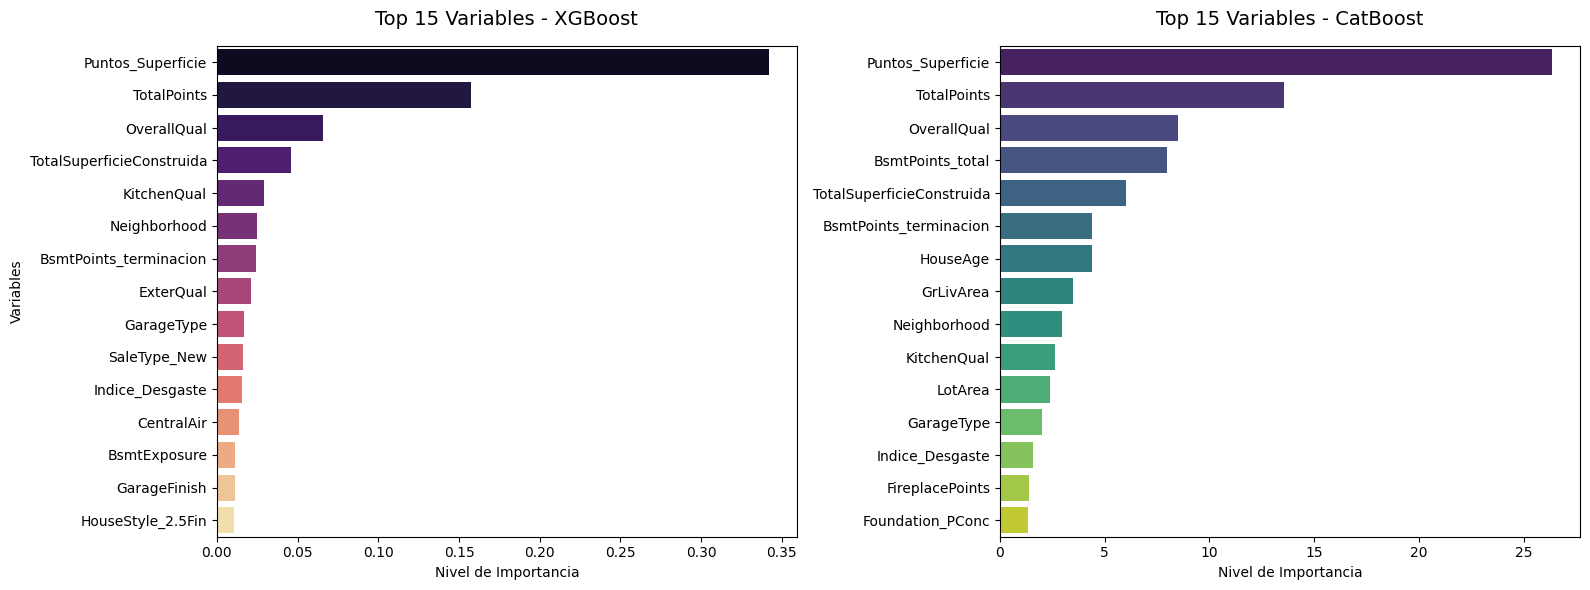

In [194]:
mejor_xgb = grid_xgrboost_search.best_estimator_
mejor_cat = grid_catboost_search.best_estimator_

importancia_xgb = mejor_xgb.feature_importances_

df_importancia_xgb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia_XGBoost': importancia_xgb
}).sort_values(by='Importancia_XGBoost', ascending=False)

importancia_cat = mejor_cat.get_feature_importance()

df_importancia_cat = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia_CatBoost': importancia_cat
}).sort_values(by='Importancia_CatBoost', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x='Importancia_XGBoost',
    y='Variable',
    data=df_importancia_xgb.head(15),
    palette='magma',
    ax=axes[0]
)
axes[0].set_title('Top 15 Variables - XGBoost', fontsize=14, pad=15)
axes[0].set_xlabel('Nivel de Importancia')
axes[0].set_ylabel('Variables')

sns.barplot(
    x='Importancia_CatBoost',
    y='Variable',
    data=df_importancia_cat.head(15),
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Top 15 Variables - CatBoost', fontsize=14, pad=15)
axes[1].set_xlabel('Nivel de Importancia')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

##Grafico Valor real vs Prediccion

### Evaluación de XGBoost: Valores Reales vs. Predichos

Las imágenes presentan gráficos de dispersión que evalúan el rendimiento del modelo **XGBoost**, comparando los precios reales frente a las predicciones generadas. Ambas gráficas muestran un comportamiento prácticamente idéntico.

**Observaciones principales:**

* **Alta correlación general:** La mayoría de las predicciones (puntos azules) siguen fielmente la línea roja punteada que representa la predicción perfecta (y=x). Esto indica un buen ajuste general del modelo.
* **Precisión en el segmento medio/bajo:** El algoritmo muestra un rendimiento excelente y con un margen de error bastante acotado en el rango de precios que va hasta los 250,000.
* **Mayor varianza en valores altos:** A medida que los precios reales superan la barrera de los 300,000, los puntos comienzan a dispersarse más respecto a la línea ideal. Esto evidencia que al modelo le resulta más difícil predecir con exactitud los valores más altos o atípicos (heterocedasticidad).

###XGBoost

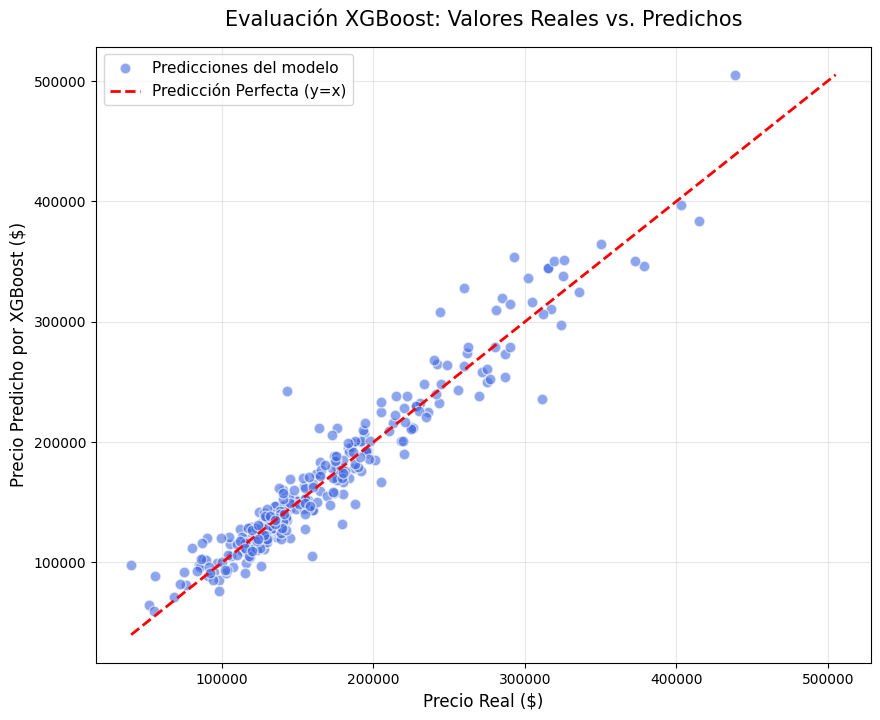

In [188]:

plt.figure(figsize=(10, 8))

plt.scatter(y_valid, grid_prediccion_xgrboost, alpha=0.6, color='royalblue', edgecolors='w', s=60, label='Predicciones del modelo')


min_val = min(y_valid.min(), grid_prediccion_xgrboost.min())
max_val = max(y_valid.max(), grid_prediccion_xgrboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title('Evaluación XGBoost: Valores Reales vs. Predichos', fontsize=15, pad=15)
plt.xlabel('Precio Real ($)', fontsize=12)
plt.ylabel('Precio Predicho por XGBoost ($)', fontsize=12)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

###Catboost

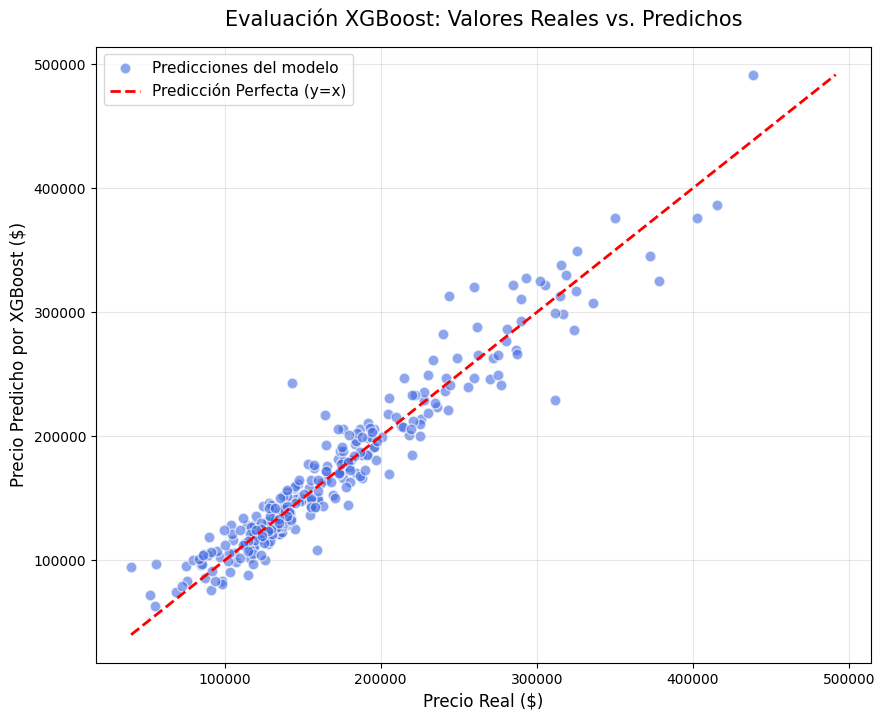

In [189]:

plt.figure(figsize=(10, 8))

plt.scatter(y_valid, prediccion_catboost, alpha=0.6, color='royalblue', edgecolors='w', s=60, label='Predicciones del modelo')


min_val = min(y_valid.min(), prediccion_catboost.min())
max_val = max(y_valid.max(), prediccion_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title('Evaluación XGBoost: Valores Reales vs. Predichos', fontsize=15, pad=15)
plt.xlabel('Precio Real ($)', fontsize=12)
plt.ylabel('Precio Predicho por XGBoost ($)', fontsize=12)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

##Grafico diferencia de precios

### Evaluación de XGBoost: Análisis de Residuos

Las imágenes muestran un **gráfico de dispersión de los residuos** (la diferencia entre el precio real y el predicho) en función de los valores predichos por el modelo XGBoost. Ambas gráficas son idénticas.

**Observaciones principales:**

* **Distribución en torno al error cero:** La mayor parte de los puntos (verdes) se agrupa cerca de la línea roja punteada (error cero). Esto es una buena señal, ya que indica que el modelo no tiene un sesgo sistemático grave (es decir, no tiende a sobreestimar o subestimar de forma constante en todo el conjunto de datos).
* **Heterocedasticidad evidente:** Se puede notar claramente que la dispersión de los errores forma una especie de "cono" o embudo que se abre hacia la derecha. A medida que el precio predicho aumenta (eje X), la varianza de los residuos también crece significativamente (eje Y).
* **Mayor incertidumbre en precios altos:** Esto confirma visualmente que el modelo es mucho más preciso y consistente para propiedades de menor valor (por debajo de los 200,000). Para las propiedades más caras (superiores a 300,000), los errores se vuelven mucho más grandes, llegando a tener fallos de predicción de hasta -$100,000 o +$75,000.

###XGBoost

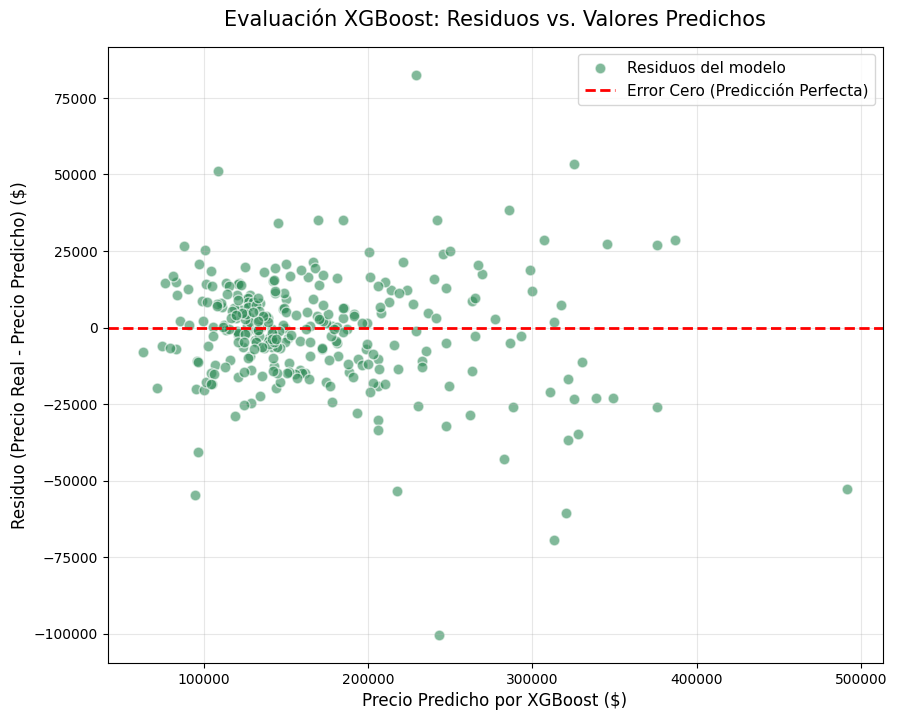

In [191]:
plt.figure(figsize=(10, 8))

residuos = y_valid - prediccion_catboost
plt.scatter(prediccion_catboost, residuos, alpha=0.6, color='seagreen', edgecolors='w', s=60, label='Residuos del modelo')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Error Cero (Predicción Perfecta)')

plt.title('Evaluación XGBoost: Residuos vs. Valores Predichos', fontsize=15, pad=15)
plt.xlabel('Precio Predicho por XGBoost ($)', fontsize=12)
plt.ylabel('Residuo (Precio Real - Precio Predicho) ($)', fontsize=12)

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

###Catboost

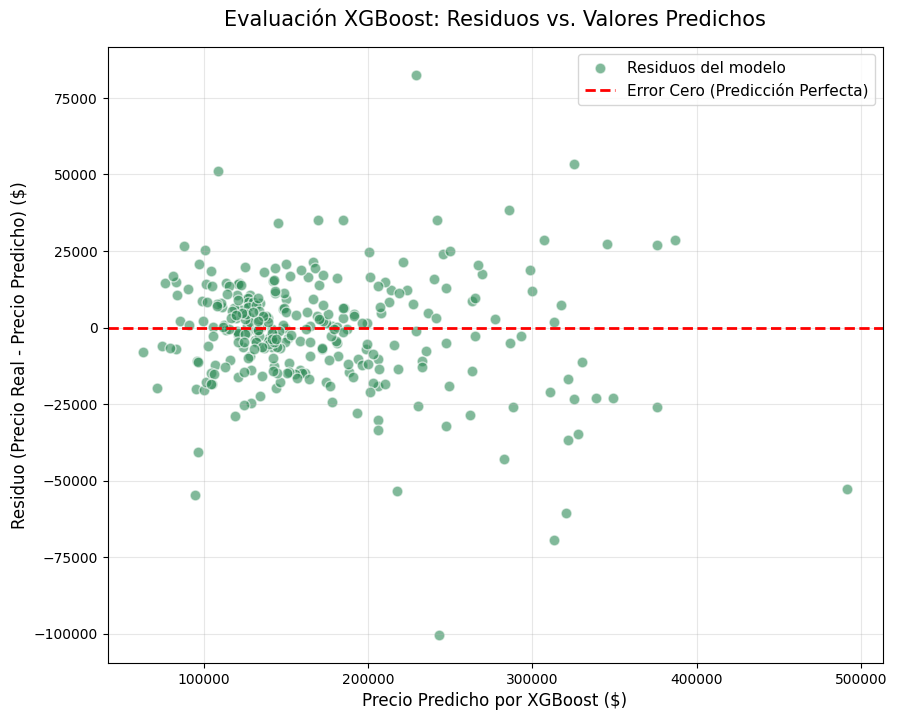

In [195]:
plt.figure(figsize=(10, 8))

residuos = y_valid - prediccion_catboost

plt.scatter(prediccion_catboost, residuos, alpha=0.6, color='seagreen', edgecolors='w', s=60, label='Residuos del modelo')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Error Cero (Predicción Perfecta)')

plt.title('Evaluación XGBoost: Residuos vs. Valores Predichos', fontsize=15, pad=15)
plt.xlabel('Precio Predicho por XGBoost ($)', fontsize=12)
plt.ylabel('Residuo (Precio Real - Precio Predicho) ($)', fontsize=12)

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

#Conclusion

### Conclusión: Evaluación XGBoost vs. CatBoost

El análisis comparativo de las métricas revela un **empate técnico** entre ambos algoritmos. Los dos modelos presentan un rendimiento predictivo sobresaliente y sumamente robusto, con diferencias relativas menores al 1% en todos los indicadores evaluados.

**Principales hallazgos:**

* **Alta precisión compartida:** Ambos modelos logran explicar más del 92.4% de la varianza en los datos (R² > 0.92), lo cual indica una excelente capacidad para capturar los patrones subyacentes.
* **Ligera ventaja global para CatBoost:** Este modelo logra una mejora marginal en las métricas de error promedio y cuadrático. Su MAE y RMSE son aproximadamente un 0.6% y 0.5% menores que los de XGBoost, lo que sugiere un ajuste general sutilmente más preciso.
* **Mejor control de errores extremos en XGBoost:** Por otro lado, XGBoost demuestra una levísima superioridad al lidiar con los casos más difíciles. Su error máximo (*Max Error*) es unos $600 inferior al de CatBoost, y su porcentaje de error absoluto medio (MAPE) es apenas más bajo (8.46% frente a 8.51%).

**Veredicto:**
Dado que las diferencias en precisión matemática son insignificantes en términos prácticos, la decisión final de qué modelo utilizar no debería recaer únicamente en estas métricas. Se sugiere definir el modelo ganador evaluando **criterios de negocio y eficiencia computacional**, tales como el tiempo que tarda cada uno en entrenarse, la velocidad para generar nuevas predicciones o la facilidad de integración en el entorno de producción.

In [201]:
metrics_xgb = {
    "R2 Score": r2_score(y_valid, grid_prediccion_xgrboost),
    "MAE (Absoluto)": mean_absolute_error(y_valid, grid_prediccion_xgrboost),
    "MSE (Cuadrático)": mean_squared_error(y_valid, grid_prediccion_xgrboost),
    "RMSE (Raíz)": np.sqrt(mean_squared_error(y_valid, grid_prediccion_xgrboost)),
    "MAPE (Porcentaje)": mean_absolute_percentage_error(y_valid, grid_prediccion_xgrboost) * 100,
    "Max Error (Peor Fallo)": max_error(y_valid, grid_prediccion_xgrboost)
}

metrics_cat = {
    "R2 Score": r2_score(y_valid, prediccion_catboost),
    "MAE (Absoluto)": mean_absolute_error(y_valid, prediccion_catboost),
    "MSE (Cuadrático)": mean_squared_error(y_valid, prediccion_catboost),
    "RMSE (Raíz)": np.sqrt(mean_squared_error(y_valid, prediccion_catboost)),
    "MAPE (Porcentaje)": mean_absolute_percentage_error(y_valid, prediccion_catboost) * 100,
    "Max Error (Peor Fallo)": max_error(y_valid, prediccion_catboost)
}

df_comparacion = pd.DataFrame([metrics_xgb, metrics_cat], index=["XGBoost (Grid)", "CatBoost (Grid)"]).T
df_comparacion["Dif (%)"] = ((df_comparacion["CatBoost (Grid)"] - df_comparacion["XGBoost (Grid)"]) / df_comparacion["XGBoost (Grid)"]) * 100

df_comparacion

,XGBoost (Grid),CatBoost (Grid),Dif (%)
R2 Score,9.246315e-01,9.253625e-01,0.079057
MAE (Absoluto),1.308522e+04,1.300749e+04,-0.594010
MSE (Cuadrático),3.412823e+08,3.379723e+08,-0.969880
RMSE (Raíz),1.847383e+04,1.838402e+04,-0.486122
MAPE (Porcentaje),8.465417e+00,8.511594e+00,0.545473
Max Error (Peor Fallo),9.972600e+04,1.003415e+05,0.617167
